# B2 — ConvNeXt V2-T + MC Dropout (T=30) — corrected v3.3

This notebook keeps B2 strictly as the **ConvNeXt V2-T + cross-entropy + MC Dropout (T=30)** baseline.


In [ ]:
#@title 0. mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#@title 1. Install dependencies
!pip -q install scikit-learn scipy matplotlib pandas pillow tqdm thop timm

In [ ]:
#@title 2. Imports and global configuration
import os, json, math, time, copy, random, warnings, gc, hashlib
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm
from thop import profile

warnings.filterwarnings('ignore')
SEED=42
NUM_CLASSES=3
CLASS_NAMES=['benign','indeterminate','malignant']
IMG_SIZE=224
BATCH_SIZE=32
NUM_WORKERS=2
MAX_EPOCHS=50
EARLY_STOPPING_PATIENCE=10
LEARNING_RATE=1e-4
MIN_LEARNING_RATE=1e-6
WEIGHT_DECAY=0.01
MC_T=30
DROPOUT_P=0.5
ECE_BINS=15
REJECTION_COVERAGES=np.linspace(0.10,1.00,20)
TIMM_MODEL_NAME='convnextv2_tiny.fcmae_ft_in1k'
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',DEVICE)


Device: cuda


In [ ]:
#@title 3. Reproducibility
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass
seed_everything(SEED)

In [ ]:
#@title 4. Mount Drive and create B2 experiment structure

MYDRIVE=Path('/content/drive/MyDrive')
PREPROCESSING_ROOT=MYDRIVE/'Thesis_Work/LIDC_Thesis'
FOLDER_RTF_ROOT=MYDRIVE/'LIDC_Thesis'
if PREPROCESSING_ROOT.exists():
    PROJECT_ROOT=PREPROCESSING_ROOT
elif FOLDER_RTF_ROOT.exists():
    PROJECT_ROOT=FOLDER_RTF_ROOT
else:
    raise FileNotFoundError(f'Expected {PREPROCESSING_ROOT} or {FOLDER_RTF_ROOT}')

LIDC_ROOT=PROJECT_ROOT/'LIDC'
PROCESSED_ROOT=LIDC_ROOT/'processed'
PATCH_ROOT=PROCESSED_ROOT/'patches'
METADATA_ROOT=PROCESSED_ROOT/'metadata'
PREPROCESS_CONFIG=LIDC_ROOT/'preprocessing'/'configs'/'preprocessing_config.yaml'
CLASS_MAPPING_JSON=LIDC_ROOT/'preprocessing'/'configs'/'class_mapping.json'
SHARED_RUN_CONFIG=METADATA_ROOT/'shared_pipeline_config.json'
FOLD_ASSIGNMENTS=METADATA_ROOT/'fold_assignments.csv'
FOLD_HASH_FILE=METADATA_ROOT/'fold_assignments.sha256'

B2_ROOT=PROJECT_ROOT/'experiments'/'B2_ConvNeXtV2T_MC_Dropout_T30'
NOTEBOOK_ROOT=B2_ROOT/'notebooks'
CONFIG_ROOT=B2_ROOT/'configs'
SPLIT_ROOT=B2_ROOT/'splits'
CHECKPOINT_ROOT=B2_ROOT/'checkpoints'
PREDICTION_ROOT=B2_ROOT/'predictions'
PRED_DET_ROOT=PREDICTION_ROOT/'deterministic'
PRED_MC_ROOT=PREDICTION_ROOT/'mc_dropout_T30'
METRICS_ROOT=B2_ROOT/'metrics'
METRICS_CLASS=METRICS_ROOT/'classification'
METRICS_CAL=METRICS_ROOT/'calibration'
METRICS_UQ=METRICS_ROOT/'uncertainty'
METRICS_EFF=METRICS_ROOT/'efficiency'
GRADCAM_ROOT=B2_ROOT/'gradcam'
PLOT_ROOT=B2_ROOT/'plots'
LOG_ROOT=B2_ROOT/'logs'
REPORT_ROOT=B2_ROOT/'reports'

for p in [NOTEBOOK_ROOT,CONFIG_ROOT,SPLIT_ROOT,CHECKPOINT_ROOT,PRED_DET_ROOT,PRED_MC_ROOT,
          METRICS_CLASS,METRICS_CAL,METRICS_UQ,METRICS_EFF,GRADCAM_ROOT,LOG_ROOT,REPORT_ROOT]:
    p.mkdir(parents=True,exist_ok=True)
for sub in ['training_curves','confusion_matrices','roc_curves','calibration_diagrams',
            'reliability_diagrams','rejection_curves']:
    (PLOT_ROOT/sub).mkdir(parents=True,exist_ok=True)
for f in range(1,6):
    (SPLIT_ROOT/f'fold_{f}').mkdir(parents=True,exist_ok=True)
    (CHECKPOINT_ROOT/f'fold_{f}').mkdir(parents=True,exist_ok=True)
    (GRADCAM_ROOT/f'fold_{f}').mkdir(parents=True,exist_ok=True)

METADATA_CSV=METADATA_ROOT/'lidc_patches_metadata.csv'
DETAILED_METADATA_CSV=METADATA_ROOT/'detailed_nodule_metadata.csv'
print('PROJECT_ROOT:',PROJECT_ROOT)
print('B2_ROOT:',B2_ROOT)


PROJECT_ROOT: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis
B2_ROOT: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B2_ConvNeXtV2T_MC_Dropout_T30


## 5. Expected preprocessing artifacts

B2 uses `LIDC/processed/metadata/lidc_patches_metadata.csv` as the source of truth. Each eligible nodule row points to a float32 `224×224` `.npy` patch under `LIDC/processed/patches/{benign,indeterminate,malignant}/`. The `.npy` values are already lung-windowed and rescaled to `[0,1]`. PNG files under `processed/previews/` are quality-control previews only and are not model inputs.

In [ ]:
#@title 6. Load authoritative preprocessing contract and verify shared folds
for required_path in [PREPROCESS_CONFIG,CLASS_MAPPING_JSON,SHARED_RUN_CONFIG,
                      METADATA_CSV,FOLD_ASSIGNMENTS,FOLD_HASH_FILE]:
    if not required_path.exists():
        raise FileNotFoundError(f'Missing required preprocessing artifact: {required_path}')

with open(PREPROCESS_CONFIG) as f:
    PRE_CFG=yaml.safe_load(f)
with open(CLASS_MAPPING_JSON) as f:
    LABEL_MAP=json.load(f)
with open(SHARED_RUN_CONFIG) as f:
    SHARED_CFG=json.load(f)

INV_LABEL_MAP={v:k for k,v in LABEL_MAP.items()}
PILOT_MAX_PATIENTS=SHARED_CFG.get('PILOT_MAX_PATIENTS',None)

expected_hash=FOLD_HASH_FILE.read_text().strip()
actual_hash=hashlib.sha256(FOLD_ASSIGNMENTS.read_bytes()).hexdigest()
if actual_hash != expected_hash:
    raise RuntimeError(f'Fold-file SHA-256 mismatch: expected {expected_hash}, got {actual_hash}')
if SHARED_CFG.get('fold_assignments_sha256') not in (None, expected_hash):
    raise RuntimeError('shared_pipeline_config.json fold hash disagrees with fold_assignments.sha256')

df=pd.read_csv(METADATA_CSV)
required={'nodule_id','patient_id','label_name','label_id','n_radiologists','diameter_mm',
          'variance_normalized','alignment_mask','patch_path','fold'}
missing=required-set(df.columns)
if missing:
    raise ValueError(f'Missing authoritative preprocessing columns: {sorted(missing)}')

assert PRE_CFG['selection']=={'minimum_diameter_mm':3.0,'minimum_radiologists':3}
assert PRE_CFG['labels']['num_classes']==3
assert PRE_CFG['crop_geometry']['output_size_px']==224
assert PRE_CFG['crop_geometry']['target_spacing_mm']==1.0
assert PRE_CFG['crop_geometry']['field_of_view_mm']==64.0
assert LABEL_MAP=={'benign':0,'indeterminate':1,'malignant':2}
assert (df.diameter_mm>=3).all() and (df.n_radiologists>=3).all()

# Fold file is patient-only and is the authority. Verify metadata rather than creating folds here.
fold_df=pd.read_csv(FOLD_ASSIGNMENTS,dtype={'patient_id':str})
fold_df['patient_id']=fold_df.patient_id.astype(str)
if fold_df.patient_id.duplicated().any():
    raise RuntimeError('fold_assignments.csv must contain exactly one row per patient.')
if not set(fold_df.fold.unique()).issubset({1,2,3,4,5}):
    raise RuntimeError('Invalid fold ID in fold_assignments.csv')

df['patient_id']=df.patient_id.astype(str)
check=df[['patient_id','fold']].merge(fold_df,on='patient_id',how='left',suffixes=('_metadata','_shared'),validate='many_to_one')
if check.fold_shared.isna().any():
    raise RuntimeError('Metadata contains patients absent from fold_assignments.csv')
if not np.array_equal(check.fold_metadata.astype(int).to_numpy(),check.fold_shared.astype(int).to_numpy()):
    raise RuntimeError('Metadata fold column disagrees with authoritative fold_assignments.csv')

df['patch_path']=df.patch_path.astype(str)
if not df.patch_path.str.lower().str.endswith('.npy').all():
    raise ValueError('B2 requires preprocessing .npy patch artifacts; PNGs are previews only.')
missing_files=[p for p in df.patch_path if not Path(p).exists()]
if missing_files:
    raise FileNotFoundError(f'{len(missing_files)} .npy patches missing; example: {missing_files[0]}')

# IMPORTANT: no local pilot truncation. Preprocessing owns cohort selection.
print('Mode:', 'PILOT' if PILOT_MAX_PATIENTS is not None else 'FULL')
print('PILOT_MAX_PATIENTS:',PILOT_MAX_PATIENTS)
print('Fold SHA-256:',actual_hash)
print('Patches:',len(df),'Patients:',df.patient_id.nunique())
display(df.groupby(['fold','label_name']).size().unstack(fill_value=0))


Mode: FULL
PILOT_MAX_PATIENTS: None
Fold SHA-256: 6579bbae4001911dbeb74213340e7846c3dcc2d03f915ed501c0ec339446a060
Patches: 48 Patients: 21


label_name,benign,indeterminate,malignant
fold,,,
1,1,0,1
2,1,14,4
3,0,5,1
4,1,9,1
5,2,5,3


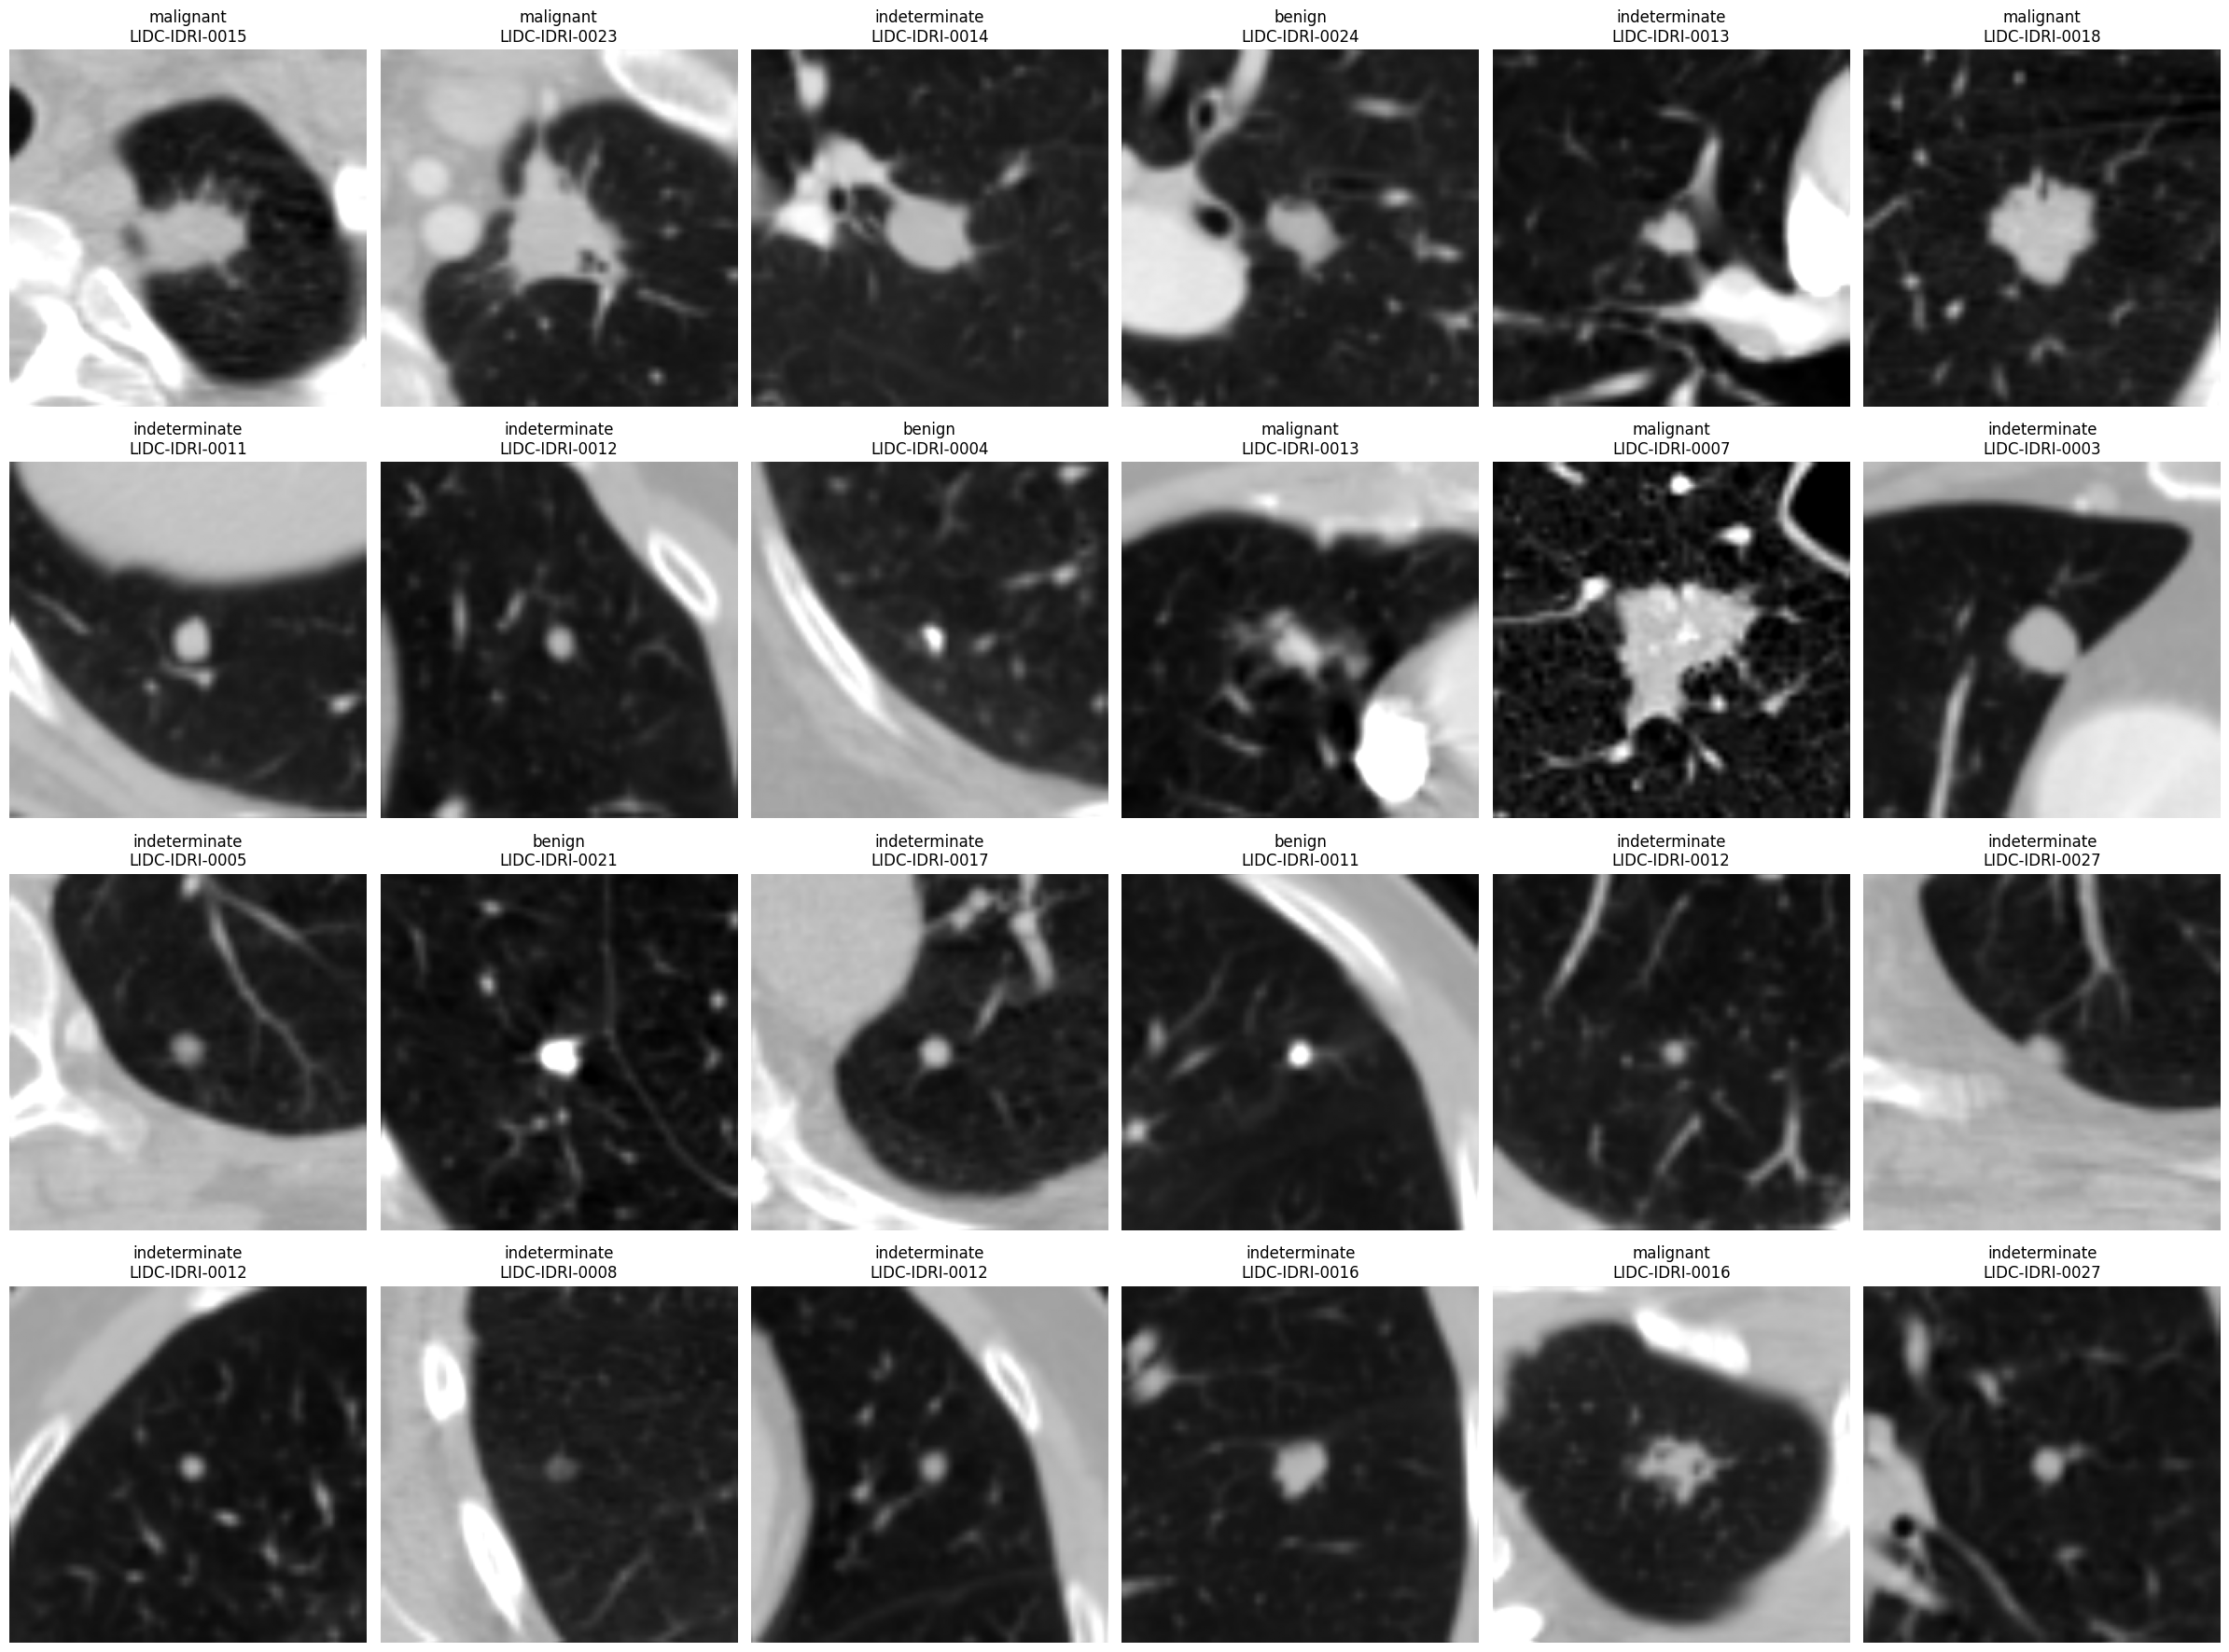

In [ ]:
#@title 7. Optional: inspect sample NPY patches
def show_samples(frame,n=24):
    sample=frame.sample(min(n,len(frame)),random_state=SEED); fig,axes=plt.subplots(4,6,figsize=(24,18)); axes=np.asarray(axes).reshape(-1)
    for ax,(_,row) in zip(axes,sample.iterrows()):
        img=np.load(row['patch_path'],allow_pickle=False); ax.imshow(img,cmap='gray',vmin=0,vmax=1); ax.set_title(f"{row['label_name']}\n{row['patient_id']}"); ax.axis('off')
    for ax in axes[len(sample):]: ax.axis('off')
    plt.tight_layout(); plt.show()
show_samples(df)

In [ ]:
#@title 8. NPY dataset and shared training-time augmentation
# Patches are already physically normalized by preprocessing, HU-clipped [-1000,400],
# scaled to [0,1], and resized to 224x224. Do not window/rescale again.
IMAGENET_MEAN=torch.tensor([0.485,0.456,0.406],dtype=torch.float32)[:,None,None]
IMAGENET_STD=torch.tensor([0.229,0.224,0.225],dtype=torch.float32)[:,None,None]

aug_cfg=PRE_CFG['training_augmentation_not_applied_during_preprocessing']
assert aug_cfg['horizontal_flip'] and aug_cfg['vertical_flip']
assert float(aug_cfg['rotation_degrees'])==15
assert float(aug_cfg['translation_fraction'])==0.10

train_aug=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(float(aug_cfg['rotation_degrees']),fill=0.0),
    transforms.RandomAffine(0,translate=(float(aug_cfg['translation_fraction']),
                                         float(aug_cfg['translation_fraction'])),fill=0.0)
])

def prepare_tensor(arr,training=False):
    arr=np.asarray(arr,dtype=np.float32)
    if arr.shape!=(224,224) or not np.isfinite(arr).all() or arr.min()<-1e-5 or arr.max()>1.00001:
        raise ValueError(f'Invalid preprocessed patch: shape={arr.shape}, range=({arr.min()},{arr.max()})')
    x=torch.from_numpy(arr).unsqueeze(0)
    if training:
        x=train_aug(x)
    x=x.repeat(3,1,1)
    return (x-IMAGENET_MEAN)/IMAGENET_STD

class LIDCPatchDataset(Dataset):
    def __init__(self,dataframe,training=False):
        self.df=dataframe.reset_index(drop=True).copy()
        self.training=training
    def __len__(self):
        return len(self.df)
    def __getitem__(self,idx):
        r=self.df.iloc[idx]
        x=prepare_tensor(np.load(r.patch_path,allow_pickle=False),self.training)
        return {
            'image':x,
            'label':torch.tensor(int(r.label_id),dtype=torch.long),
            'patient_id':str(r.patient_id),
            'nodule_id':str(r.nodule_id),
            'patch_path':str(r.patch_path),
            'variance_normalized':torch.tensor(float(r.variance_normalized),dtype=torch.float32),
            'alignment_mask':torch.tensor(int(r.alignment_mask),dtype=torch.long)
        }


In [ ]:
#@title 9. Shared outer folds + patient-disjoint stratified validation
def create_split_for_fold(metadata_df,test_fold,seed=SEED):
    test_df=metadata_df[metadata_df.fold==test_fold].copy()
    trainval_df=metadata_df[metadata_df.fold!=test_fold].copy()

    # Approximately 10% validation using patient-grouped stratification.
    # No GroupShuffleSplit/random fallback: failure is explicit.
    sgkf=StratifiedGroupKFold(n_splits=10,shuffle=True,random_state=seed+int(test_fold))
    try:
        train_idx,val_idx=next(sgkf.split(
            np.zeros(len(trainval_df)),
            trainval_df.label_id.to_numpy(),
            groups=trainval_df.patient_id.astype(str).to_numpy()
        ))
    except Exception as e:
        raise RuntimeError(f'Fold {test_fold}: stratified patient validation split failed: {e}') from e

    train_df=trainval_df.iloc[train_idx].copy()
    val_df=trainval_df.iloc[val_idx].copy()

    A=set(train_df.patient_id.astype(str))
    B=set(val_df.patient_id.astype(str))
    C=set(test_df.patient_id.astype(str))
    if not (A.isdisjoint(B) and A.isdisjoint(C) and B.isdisjoint(C)):
        raise AssertionError(f'Patient leakage detected in fold {test_fold}')
    if len(test_df)==0 or len(val_df)==0 or len(train_df)==0:
        raise RuntimeError(f'Empty train/validation/test split in fold {test_fold}')
    return train_df,val_df,test_df

folds=[]
manifest=[]
for fold in range(1,6):
    tr,va,te=create_split_for_fold(df,fold)
    fd=SPLIT_ROOT/f'fold_{fold}'
    tr.to_csv(fd/'train.csv',index=False)
    va.to_csv(fd/'validation.csv',index=False)
    te.to_csv(fd/'test.csv',index=False)
    folds.append({'fold':fold,'train':tr,'val':va,'test':te})
    for name,fr in [('train',tr),('validation',va),('test',te)]:
        manifest.append({
            'fold':fold,'split':name,'patches':len(fr),'patients':fr.patient_id.nunique(),
            **{c:int((fr.label_id==i).sum()) for i,c in enumerate(CLASS_NAMES)}
        })

manifest_df=pd.DataFrame(manifest)
manifest_df.to_csv(SPLIT_ROOT/'all_folds_summary.csv',index=False)
display(manifest_df)


,fold,split,patches,patients,benign,indeterminate,malignant
0,1,train,44,18,4,31,9
1,1,validation,2,1,0,2,0
2,1,test,2,2,1,0,1
3,2,train,28,15,4,19,5
4,2,validation,1,1,0,0,1
5,2,test,19,5,1,14,4
6,3,train,41,16,5,28,8
7,3,validation,1,1,0,0,1
8,3,test,6,4,0,5,1
9,4,train,36,15,3,24,9


In [ ]:
#@title 10. DataLoader construction
def make_loaders(train_df,val_df,test_df):
    kw=dict(batch_size=BATCH_SIZE,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
    return DataLoader(LIDCPatchDataset(train_df,True),shuffle=True,**kw),DataLoader(LIDCPatchDataset(val_df,False),shuffle=False,**kw),DataLoader(LIDCPatchDataset(test_df,False),shuffle=False,**kw)

In [ ]:
#@title 11. B2 ConvNeXt V2-T with dropout before the final classifier
class ConvNeXtV2TMCDropout(nn.Module):
    def __init__(self, num_classes=3, dropout_p=0.5, pretrained=True, model_name=TIMM_MODEL_NAME):
        super().__init__()
        # timm removes the original ImageNet classifier when num_classes=0.
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        in_features = int(self.backbone.num_features)
        self.dropout = nn.Dropout(p=dropout_p)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        spatial = self.backbone.forward_features(x)
        pooled = self.backbone.forward_head(spatial, pre_logits=True)
        return self.classifier(self.dropout(pooled))

    def enable_dropout(self):
        # Keep normalization layers in eval mode while re-enabling dropout for MC inference.
        for module in self.modules():
            if isinstance(module, nn.Dropout):
                module.train()

model = ConvNeXtV2TMCDropout(
    num_classes=NUM_CLASSES,
    dropout_p=DROPOUT_P,
    pretrained=True
).to(DEVICE)

print('Backbone:', TIMM_MODEL_NAME)
print('Feature dimension:', model.backbone.num_features)
print('Final classifier:', model.classifier)


model.safetensors: reconstructing file:   0%|          |  0.00B /  115MB            

model.safetensors: downloading bytes:           |  0.00B            

Backbone: convnextv2_tiny.fcmae_ft_in1k
Feature dimension: 768
Final classifier: Linear(in_features=768, out_features=3, bias=True)


In [ ]:
#@title 12. Required evaluation metrics
EPS=1e-12

def multiclass_brier_score(y_true,probs):
    oh=np.eye(NUM_CLASSES)[np.asarray(y_true,dtype=int)]
    return float(np.mean(np.sum((np.asarray(probs)-oh)**2,axis=1)))

def expected_calibration_error(y_true,probs,n_bins=15):
    y_true=np.asarray(y_true); probs=np.asarray(probs)
    conf=probs.max(1); pred=probs.argmax(1); correct=(pred==y_true).astype(float)
    edges=np.linspace(0,1,n_bins+1); ece=0.0
    for i,(lo,hi) in enumerate(zip(edges[:-1],edges[1:])):
        m=(conf>=lo)&(conf<=hi) if i==0 else (conf>lo)&(conf<=hi)
        if m.any(): ece+=m.mean()*abs(correct[m].mean()-conf[m].mean())
    return float(ece)

def safe_macro_auroc(y_true,probs):
    y=np.asarray(y_true,dtype=int); p=np.asarray(probs)
    yb=label_binarize(y,classes=[0,1,2]); vals=[]
    for k in range(NUM_CLASSES):
        if len(np.unique(yb[:,k]))<2: vals.append(np.nan)
        else: vals.append(roc_auc_score(yb[:,k],p[:,k]))
    return float(np.nanmean(vals)) if np.isfinite(vals).any() else np.nan

def compute_classification_metrics(y_true,probs):
    y=np.asarray(y_true,dtype=int); p=np.asarray(probs,dtype=float); pred=p.argmax(1)
    return {'accuracy':float(accuracy_score(y,pred)),
            'macro_f1':float(f1_score(y,pred,average='macro',zero_division=0)),
            'auroc_ovr_macro':safe_macro_auroc(y,p),
            'brier_score':multiclass_brier_score(y,p),
            'ece_15':expected_calibration_error(y,p,ECE_BINS),
            'nll':float(-np.mean(np.log(np.clip(p[np.arange(len(y)),y],EPS,1.0))))}

In [ ]:
#@title 13. Training and validation utilities
def standard_forward(model,loader,criterion):
    model.eval()
    total_loss=0.0
    all_labels,all_probs=[],[]
    with torch.no_grad():
        for batch in loader:
            images=batch['image'].to(DEVICE,non_blocking=True)
            labels=batch['label'].to(DEVICE,non_blocking=True)
            logits=model(images)
            loss=criterion(logits,labels)
            probs=torch.softmax(logits,dim=1)
            total_loss+=loss.item()*images.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    probabilities=np.concatenate(all_probs,axis=0)
    labels=np.asarray(all_labels)
    metrics=compute_classification_metrics(labels,probabilities)
    metrics['loss']=float(total_loss/len(loader.dataset))
    return metrics,labels,probabilities

def train_one_epoch(model,loader,optimizer,criterion):
    model.train()
    running_loss=0.0
    correct=0
    total=0
    for batch in loader:
        images=batch['image'].to(DEVICE,non_blocking=True)
        labels=batch['label'].to(DEVICE,non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits=model(images)
        loss=criterion(logits,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()*images.size(0)
        correct+=(logits.argmax(1)==labels).sum().item()
        total+=images.size(0)
    return running_loss/len(loader.dataset), correct/max(total,1)


In [ ]:
#@title 14. Train one fold with AdamW, cosine annealing, and Brier-based early stopping
def train_fold(train_loader, val_loader, fold_number, run_dir):
    model = ConvNeXtV2TMCDropout(
        num_classes=NUM_CLASSES,
        dropout_p=DROPOUT_P,
        pretrained=True
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        betas=(0.9, 0.999),
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=MAX_EPOCHS,
        eta_min=MIN_LEARNING_RATE
    )

    history = []
    best_state = None
    best_val_brier = float("inf")
    epochs_without_improvement = 0

    run_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, criterion)
        val_metrics, _, _ = standard_forward(model, val_loader, criterion)
        scheduler.step()

        record = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "train_accuracy": float(train_accuracy),
            "learning_rate": float(optimizer.param_groups[0]["lr"]),
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }
        history.append(record)

        print(
            f"Fold {fold_number} | Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | train_acc={train_accuracy:.4f} | "
            f"val_brier={val_metrics['brier_score']:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["brier_score"] < best_val_brier:
            best_val_brier = val_metrics["brier_score"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0

            torch.save(
                {
                    "fold": fold_number,
                    "epoch": epoch,
                    "model_state_dict": best_state,
                    "best_val_brier": best_val_brier,
                    "config": {
                        "backbone": "ConvNeXt V2-T",
                        "dropout_p": DROPOUT_P,
                        "mc_t": MC_T,
                        "seed": SEED
                    }
                },
                CHECKPOINT_ROOT / f'fold_{fold_number}' / 'best_model.pt'
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)
    pd.DataFrame(history).to_csv(LOG_ROOT / f'fold_{fold_number}.log', index=False)
    torch.save({'fold':fold_number,'model_state_dict':model.state_dict()}, CHECKPOINT_ROOT/f'fold_{fold_number}'/'final_model.pt')
    return model, pd.DataFrame(history)


In [ ]:
#@title 15. MC Dropout inference (T=30)
def enable_mc_dropout(model):
    # Correct policy: BatchNorm and all non-dropout layers remain in eval mode.
    model.eval()
    for m in model.modules():
        if isinstance(m,nn.Dropout):
            m.train()

@torch.no_grad()
def mc_dropout_predict(model,loader,T=MC_T):
    enable_mc_dropout(model)
    passes=[]
    labels=None
    metadata=None
    for t in tqdm(range(T),desc=f'MC Dropout T={T}',leave=False):
        pp=[]; yy=[]; mm=[]
        for batch in loader:
            x=batch['image'].to(DEVICE,non_blocking=True)
            probs=torch.softmax(model(x),1).cpu().numpy()
            pp.append(probs)
            if t==0:
                yy.extend(batch['label'].numpy().tolist())
                vv=batch['variance_normalized'].numpy().tolist()
                mm.extend([
                    {'patient_id':p,'nodule_id':n,'patch_path':q,'variance_normalized':float(v)}
                    for p,n,q,v in zip(batch['patient_id'],batch['nodule_id'],batch['patch_path'],vv)
                ])
        passes.append(np.concatenate(pp,0))
        if t==0:
            labels=np.asarray(yy)
            metadata=mm

    mc=np.stack(passes,0)
    mean=mc.mean(0)
    clipped_mean=np.clip(mean,EPS,1)
    clipped_mc=np.clip(mc,EPS,1)
    pred_ent=-np.sum(clipped_mean*np.log(clipped_mean),axis=1)
    exp_ent=-np.mean(np.sum(clipped_mc*np.log(clipped_mc),axis=2),axis=0)
    mi=pred_ent-exp_ent
    prob_var=mc.var(0).mean(1)
    pass_labels=mc.argmax(2)
    vr=[]
    for i in range(pass_labels.shape[1]):
        counts=np.bincount(pass_labels[:,i],minlength=NUM_CLASSES)
        vr.append(1-counts.max()/T)

    return {
        'mc_probs':mc,'mean_probabilities':mean,'labels':labels,'metadata':metadata,
        'predictive_entropy':pred_ent,'mutual_information':mi,
        'mean_probability_variance':prob_var,'variation_ratio':np.asarray(vr)
    }


In [ ]:
#@title 16. Save MC predictions and core metrics
def save_mc_results(mc_results,fold_number):
    p=mc_results['mean_probabilities']
    y=mc_results['labels']
    metrics=compute_classification_metrics(y,p)
    metrics.update({
        'mean_predictive_entropy':float(mc_results['predictive_entropy'].mean()),
        'mean_mutual_information':float(mc_results['mutual_information'].mean()),
        'mean_probability_variance':float(mc_results['mean_probability_variance'].mean()),
        'mean_variation_ratio':float(mc_results['variation_ratio'].mean())
    })

    rows=[]
    for i,m in enumerate(mc_results['metadata']):
        rows.append({
            'fold':fold_number,**m,
            'true_label':int(y[i]),
            'predicted_label':int(p[i].argmax()),
            'p_benign':float(p[i,0]),
            'p_indeterminate':float(p[i,1]),
            'p_malignant':float(p[i,2]),
            # Shared qualitative-analysis contract: V and u on every EDL/MC baseline output.
            'V':float(m['variance_normalized']),
            'u':float(mc_results['predictive_entropy'][i]),
            'predictive_entropy':float(mc_results['predictive_entropy'][i]),
            'mutual_information':float(mc_results['mutual_information'][i]),
            'mean_probability_variance':float(mc_results['mean_probability_variance'][i]),
            'variation_ratio':float(mc_results['variation_ratio'][i])
        })

    pred_df=pd.DataFrame(rows)
    pred_df.to_csv(PRED_MC_ROOT/f'fold_{fold_number}_predictions.csv',index=False)
    np.save(PRED_MC_ROOT/f'fold_{fold_number}_probabilities.npy',mc_results['mc_probs'])
    pred_df[['nodule_id','patient_id','V','u','predictive_entropy','mutual_information',
             'mean_probability_variance','variation_ratio']].to_csv(
        PRED_MC_ROOT/f'fold_{fold_number}_uncertainty.csv',index=False)
    return metrics,pred_df


In [ ]:
#@title 17. Shared predictive-entropy rejection curve
def _coverage_indices(order,coverage,n):
    kept=max(1,min(n,int(math.ceil(float(coverage)*n))))
    return order[:kept]

def rejection_curve(labels,probs,uncertainty,coverages=REJECTION_COVERAGES):
    y=np.asarray(labels)
    pred=np.asarray(probs).argmax(1)
    order=np.argsort(np.asarray(uncertainty))
    rows=[]
    n=len(y)
    for coverage in coverages:
        idx=_coverage_indices(order,coverage,n)
        rows.append({'coverage':float(coverage),'n_kept':len(idx),
                     'accuracy':float(accuracy_score(y[idx],pred[idx]))})
    return pd.DataFrame(rows)

def random_rejection_curve(labels,probs,repeats=50,seed=42,coverages=REJECTION_COVERAGES):
    y=np.asarray(labels)
    pred=np.asarray(probs).argmax(1)
    n=len(y)
    rng=np.random.RandomState(seed)
    scores=np.zeros((repeats,len(coverages)),dtype=float)
    for r in range(repeats):
        order=rng.permutation(n)
        for j,coverage in enumerate(coverages):
            idx=_coverage_indices(order,coverage,n)
            scores[r,j]=accuracy_score(y[idx],pred[idx])
    return pd.DataFrame({
        'coverage':np.asarray(coverages,dtype=float),
        'accuracy':scores.mean(0),
        'accuracy_sd':scores.std(0)
    })

def save_rejection_curves(mc_results,fold):
    a=rejection_curve(mc_results['labels'],mc_results['mean_probabilities'],
                      mc_results['predictive_entropy'])
    r=random_rejection_curve(mc_results['labels'],mc_results['mean_probabilities'],
                             repeats=50,seed=SEED+fold)
    a.to_csv(METRICS_UQ/f'fold_{fold}_rejection_curves.csv',index=False)
    r.to_csv(METRICS_UQ/f'fold_{fold}_rejection_random.csv',index=False)

    plt.figure(figsize=(7,5))
    plt.plot(a.coverage,a.accuracy,label='MC predictive entropy')
    plt.plot(r.coverage,r.accuracy,label='Random')
    plt.xlabel('Coverage'); plt.ylabel('Accuracy')
    plt.title(f'Fold {fold} rejection curve')
    plt.legend(); plt.tight_layout()
    plt.savefig(PLOT_ROOT/'rejection_curves'/f'fold_{fold}.png',dpi=160)
    plt.close()

    return {
        'rejection_auc_entropy':float(np.trapezoid(a.accuracy.values,a.coverage.values)),
        'rejection_auc_random':float(np.trapezoid(r.accuracy.values,r.coverage.values))
    }


In [ ]:
#@title 18. Grad-CAM is implemented in the final XAI section (cell 26+)
# Kept empty here intentionally so all XAI-related work is at the end, as requested.

In [ ]:
#@title 19. Efficiency: parameters, FLOPs, full T=30 latency
def efficiency_metrics(model,test_loader):
    params=sum(p.numel() for p in model.parameters())
    dummy=torch.randn(1,3,IMG_SIZE,IMG_SIZE,device=DEVICE)
    try: flops,_=profile(model,inputs=(dummy,),verbose=False)
    except Exception: flops=np.nan
    single=DataLoader(test_loader.dataset,batch_size=1,shuffle=False,num_workers=0)
    times=[]; enable_mc_dropout(model)
    for j,b in enumerate(single):
        if j>=min(50,len(single.dataset)): break
        x=b['image'].to(DEVICE)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t0=time.perf_counter()
        with torch.no_grad():
            for _ in range(MC_T): _=model(x)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        times.append((time.perf_counter()-t0)*1000)
    return {'device':str(DEVICE),'parameter_count':int(params),'single_pass_flops':float(flops) if np.isfinite(flops) else np.nan,
            'mc_dropout_T30_latency_ms_per_image':float(np.mean(times)) if times else np.nan}


In [ ]:
#@title 20. Run all 5 folds
RUN_ALL_FOLDS=True; all_fold_metrics=[]
if RUN_ALL_FOLDS:
    for info in folds:
        fold=info['fold']; print('\n'+'='*72); print('B2 FOLD',fold); print('='*72)
        train_loader,val_loader,test_loader=make_loaders(info['train'],info['val'],info['test']); model,history=model, history = train_fold(train_loader,val_loader,fold,CHECKPOINT_ROOT / f"fold_{fold}")
        det_metrics,det_y,det_p=standard_forward(model,test_loader,nn.CrossEntropyLoss())
        det_rows=info['test'][['nodule_id','patient_id','patch_path','variance_normalized']].reset_index(drop=True).copy(); det_rows['V']=det_rows['variance_normalized']; det_rows['true_label']=det_y; det_rows['predicted_label']=det_p.argmax(1); det_rows[['p_benign','p_indeterminate','p_malignant']]=det_p; det_rows.to_csv(PRED_DET_ROOT/f'fold_{fold}_predictions.csv',index=False)
        mc=mc_dropout_predict(model,test_loader,T=MC_T); metrics,pred_df=save_mc_results(mc,fold); metrics.update(save_rejection_curves(mc,fold)); metrics.update(efficiency_metrics(model,test_loader)); metrics.update({'fold':fold,'test_patches':len(info['test']),'test_patients':info['test'].patient_id.nunique()})
        pd.DataFrame([{k:v for k,v in metrics.items() if k in ['fold','accuracy','macro_f1','auroc_ovr_macro']}]).to_csv(METRICS_CLASS/f'fold_{fold}_metrics.csv',index=False)
        pd.DataFrame([{k:v for k,v in metrics.items() if k in ['fold','brier_score','ece_15','nll']}]).to_csv(METRICS_CAL/f'fold_{fold}_calibration.csv',index=False)
        pd.DataFrame([{k:v for k,v in metrics.items() if k=='fold' or 'entropy' in k or 'variation' in k or 'rejection' in k}]).to_csv(METRICS_UQ/f'fold_{fold}_uncertainty.csv',index=False)
        pd.DataFrame([{k:v for k,v in metrics.items() if k in ['fold','device','parameter_count','single_pass_flops','mc_dropout_T30_latency_ms_per_image']}]).to_csv(METRICS_EFF/f'fold_{fold}_efficiency.csv',index=False)
        all_fold_metrics.append(metrics); del model; gc.collect();
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    results_df=pd.DataFrame(all_fold_metrics); results_df.to_csv(METRICS_CLASS/'fold_metrics.csv',index=False); display(results_df)



B2 FOLD 1


Fold 1 | Epoch 01 | train_loss=0.9891 | train_acc=0.4545 | val_brier=0.2026 | val_macro_f1=1.0000
Fold 1 | Epoch 02 | train_loss=0.7873 | train_acc=0.7045 | val_brier=0.0724 | val_macro_f1=1.0000
Fold 1 | Epoch 03 | train_loss=0.7750 | train_acc=0.7045 | val_brier=0.0344 | val_macro_f1=1.0000
Fold 1 | Epoch 04 | train_loss=0.7269 | train_acc=0.7045 | val_brier=0.0470 | val_macro_f1=1.0000
Fold 1 | Epoch 05 | train_loss=0.6957 | train_acc=0.7045 | val_brier=0.0658 | val_macro_f1=1.0000
Fold 1 | Epoch 06 | train_loss=0.6775 | train_acc=0.7500 | val_brier=0.0610 | val_macro_f1=1.0000
Fold 1 | Epoch 07 | train_loss=0.6056 | train_acc=0.8636 | val_brier=0.0479 | val_macro_f1=1.0000
Fold 1 | Epoch 08 | train_loss=0.5599 | train_acc=0.8864 | val_brier=0.0547 | val_macro_f1=1.0000
Fold 1 | Epoch 09 | train_loss=0.5203 | train_acc=0.7955 | val_brier=0.0537 | val_macro_f1=1.0000
Fold 1 | Epoch 10 | train_loss=0.4727 | train_acc=0.8636 | val_brier=0.0459 | val_macro_f1=1.0000
Fold 1 | Epoch 11 | 

MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]


B2 FOLD 2
Fold 2 | Epoch 01 | train_loss=1.0363 | train_acc=0.5714 | val_brier=0.9753 | val_macro_f1=0.0000
Fold 2 | Epoch 02 | train_loss=1.0199 | train_acc=0.6429 | val_brier=1.1684 | val_macro_f1=0.0000
Fold 2 | Epoch 03 | train_loss=0.8120 | train_acc=0.6786 | val_brier=1.2280 | val_macro_f1=0.0000
Fold 2 | Epoch 04 | train_loss=0.7131 | train_acc=0.6786 | val_brier=1.2342 | val_macro_f1=0.0000
Fold 2 | Epoch 05 | train_loss=0.7161 | train_acc=0.6786 | val_brier=1.2662 | val_macro_f1=0.0000
Fold 2 | Epoch 06 | train_loss=0.7950 | train_acc=0.6786 | val_brier=1.2273 | val_macro_f1=0.0000
Fold 2 | Epoch 07 | train_loss=0.6149 | train_acc=0.6786 | val_brier=1.1137 | val_macro_f1=0.0000
Fold 2 | Epoch 08 | train_loss=0.5942 | train_acc=0.7500 | val_brier=0.9652 | val_macro_f1=0.0000
Fold 2 | Epoch 09 | train_loss=0.5875 | train_acc=0.7500 | val_brier=0.8187 | val_macro_f1=0.0000
Fold 2 | Epoch 10 | train_loss=0.5040 | train_acc=0.7857 | val_brier=0.7108 | val_macro_f1=0.0000
Fold 2 | 

MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]

...


B2 FOLD 4
Fold 4 | Epoch 01 | train_loss=1.2469 | train_acc=0.1667 | val_brier=1.0019 | val_macro_f1=0.0000
Fold 4 | Epoch 02 | train_loss=0.9233 | train_acc=0.6944 | val_brier=1.2054 | val_macro_f1=0.0000
Fold 4 | Epoch 03 | train_loss=0.7813 | train_acc=0.6944 | val_brier=1.2975 | val_macro_f1=0.0000
Fold 4 | Epoch 04 | train_loss=0.7728 | train_acc=0.6667 | val_brier=1.1686 | val_macro_f1=0.0000
Fold 4 | Epoch 05 | train_loss=0.6589 | train_acc=0.7500 | val_brier=1.2568 | val_macro_f1=0.0000
Fold 4 | Epoch 06 | train_loss=0.6073 | train_acc=0.7778 | val_brier=1.3963 | val_macro_f1=0.0000
Fold 4 | Epoch 07 | train_loss=0.5109 | train_acc=0.7778 | val_brier=1.5259 | val_macro_f1=0.0000
Fold 4 | Epoch 08 | train_loss=0.4999 | train_acc=0.8056 | val_brier=1.5731 | val_macro_f1=0.0000
Fold 4 | Epoch 09 | train_loss=0.4214 | train_acc=0.8889 | val_brier=1.4948 | val_macro_f1=0.0000
Fold 4 | Epoch 10 | train_loss=0.4712 | train_acc=0.8611 | val_brier=1.5220 | val_macro_f1=0.0000
Fold 4 | 

MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]


B2 FOLD 5
Fold 5 | Epoch 01 | train_loss=0.9011 | train_acc=0.6667 | val_brier=0.2214 | val_macro_f1=1.0000
Fold 5 | Epoch 02 | train_loss=0.7761 | train_acc=0.7222 | val_brier=0.0415 | val_macro_f1=1.0000
Fold 5 | Epoch 03 | train_loss=0.7510 | train_acc=0.7222 | val_brier=0.0413 | val_macro_f1=1.0000
Fold 5 | Epoch 04 | train_loss=0.7722 | train_acc=0.7222 | val_brier=0.0774 | val_macro_f1=1.0000
Fold 5 | Epoch 05 | train_loss=0.7605 | train_acc=0.7222 | val_brier=0.1050 | val_macro_f1=1.0000
Fold 5 | Epoch 06 | train_loss=0.6834 | train_acc=0.7778 | val_brier=0.0864 | val_macro_f1=1.0000
Fold 5 | Epoch 07 | train_loss=0.6505 | train_acc=0.7778 | val_brier=0.0600 | val_macro_f1=1.0000
Fold 5 | Epoch 08 | train_loss=0.6388 | train_acc=0.7778 | val_brier=0.0478 | val_macro_f1=1.0000
Fold 5 | Epoch 09 | train_loss=0.5552 | train_acc=0.7222 | val_brier=0.0642 | val_macro_f1=1.0000
Fold 5 | Epoch 10 | train_loss=0.5368 | train_acc=0.8333 | val_brier=0.0949 | val_macro_f1=1.0000
Fold 5 | 

MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]

,accuracy,macro_f1,auroc_ovr_macro,brier_score,ece_15,nll,mean_predictive_entropy,mean_mutual_information,mean_probability_variance,mean_variation_ratio,rejection_auc_entropy,rejection_auc_random,device,parameter_count,single_pass_flops,mc_dropout_T30_latency_ms_per_image,fold,test_patches,test_patients
0,0.500000,0.333333,1.000000,0.961771,0.475288,2.063050,0.130800,0.003027,0.000077,0.000000,0.248684,0.466105,cuda,27868803,4.454804e+09,317.290262,1,2,2
1,0.684211,0.270833,0.826720,0.358490,0.162056,0.636553,0.716904,0.019992,0.003958,0.050877,0.798739,0.607191,cuda,27868803,4.454804e+09,388.082452,2,19,5
2,0.833333,0.777778,1.000000,0.130892,0.135428,0.257516,0.427264,0.011485,0.002033,0.083333,0.872368,0.775468,cuda,27868803,4.454804e+09,379.847674,3,6,4
3,0.818182,0.300000,0.437037,0.501243,0.431830,0.858958,1.039700,0.017456,0.003896,0.115152,0.636066,0.733028,cuda,27868803,4.454804e+09,362.792421,4,11,5
4,0.500000,0.222222,0.600794,0.672252,0.338928,1.187368,0.602243,0.016010,0.002612,0.016667,0.487293,0.436474,cuda,27868803,4.454804e+09,320.294483,5,10,5


In [ ]:
#@title 21. Five-fold mean ± standard deviation
if RUN_ALL_FOLDS and len(all_fold_metrics):
    results_df=pd.DataFrame(all_fold_metrics)
    rows=[]
    for c in results_df.columns:
        if c=='fold' or not pd.api.types.is_numeric_dtype(results_df[c]): continue
        v=pd.to_numeric(results_df[c],errors='coerce')
        rows.append({'metric':c,'mean':float(v.mean()) if v.notna().any() else np.nan,
                     'std':float(v.std(ddof=1)) if v.notna().sum()>1 else np.nan,'n_valid_folds':int(v.notna().sum())})
    summary_df=pd.DataFrame(rows); summary_df.to_csv(METRICS_ROOT/'B2_5fold_mean_std.csv',index=False); display(summary_df)
    f1mean=float(results_df['macro_f1'].mean())
    milestone={'M2_threshold_macro_f1':0.50,'observed_mean_macro_f1':f1mean,'passed':bool(f1mean>0.50),
               'note':'Pilot interpretation only when PILOT_MAX_PATIENTS=20.'}
    json.dump(milestone,open(REPORT_ROOT/'B2_pilot_milestone.json','w'),indent=2); print(milestone)

,metric,mean,std,n_valid_folds
0,accuracy,6.671451e-01,0.163246,5
1,macro_f1,3.808333e-01,0.225617,5
2,auroc_ovr_macro,7.729101e-01,0.249234,5
3,brier_score,5.249296e-01,0.314668,5
4,ece_15,3.087059e-01,0.154397,5
5,nll,1.000689e+00,0.683456,5
6,mean_predictive_entropy,5.833821e-01,0.337496,5
7,mean_mutual_information,1.359379e-02,0.006667,5
8,mean_probability_variance,2.515170e-03,0.001595,5
9,mean_variation_ratio,5.320574e-02,0.047213,5


{'M2_threshold_macro_f1': 0.5, 'observed_mean_macro_f1': 0.38083333333333325, 'passed': False, 'note': 'Pilot interpretation only when PILOT_MAX_PATIENTS=20.'}


In [ ]:
#@title 22. Reliability diagram helper (ECE uses 15 bins)
def save_reliability_diagram(y_true,probs,fold):
    y=np.asarray(y_true); p=np.asarray(probs); conf=p.max(1); pred=p.argmax(1); correct=(pred==y).astype(float)
    edges=np.linspace(0,1,ECE_BINS+1); xs=[]; ys=[]
    for i,(lo,hi) in enumerate(zip(edges[:-1],edges[1:])):
        m=(conf>=lo)&(conf<=hi) if i==0 else (conf>lo)&(conf<=hi)
        if m.any(): xs.append(conf[m].mean()); ys.append(correct[m].mean())
    plt.figure(figsize=(6,6)); plt.plot([0,1],[0,1],'--',label='Perfect'); plt.plot(xs,ys,marker='o',label='B2 MC Dropout')
    plt.xlabel('Mean confidence'); plt.ylabel('Accuracy'); plt.title(f'Fold {fold} reliability'); plt.legend(); plt.tight_layout()
    plt.savefig(PLOT_ROOT/f'fold_{fold}_reliability.png',dpi=160); plt.close()

# Generate from saved prediction CSVs without rerunning inference.
if RUN_ALL_FOLDS:
    for fold in range(5):
        pth=PREDICTION_ROOT/f'fold_{fold}_test_predictions.csv'
        if pth.exists():
            q=pd.read_csv(pth); probs=q[['p_benign','p_indeterminate','p_malignant']].values
            save_reliability_diagram(q.true_label.values,probs,fold)

In [ ]:
#@title 23. Save B2 configuration/provenance
experiment_config={
    'experiment':'B2_ConvNeXtV2T_MC_Dropout_T30',
    'role':'ConvNeXt V2-T softmax MC-Dropout baseline',
    'backbone':'ConvNeXt V2-T',
    'pretrained':True,
    'pretrained_model':TIMM_MODEL_NAME,
    'input_artifact':'float32 .npy from corrected preprocessing',
    'input_size':[224,224,1],
    'grayscale_replicated_to_rgb':True,
    'num_classes':3,
    'loss':'CrossEntropyLoss',
    'optimizer':'AdamW',
    'weight_decay':WEIGHT_DECAY,
    'initial_learning_rate':LEARNING_RATE,
    'minimum_learning_rate':MIN_LEARNING_RATE,
    'scheduler':'CosineAnnealingLR',
    'max_epochs':MAX_EPOCHS,
    'early_stopping_patience':EARLY_STOPPING_PATIENCE,
    'early_stopping_metric':'validation_brier_score',
    'dropout_probability':DROPOUT_P,
    'mc_dropout_T':MC_T,
    'seed':SEED,
    'batch_size':BATCH_SIZE,
    'ece_bins':ECE_BINS,
    'rejection_coverages':REJECTION_COVERAGES.tolist(),
    'augmentation':PRE_CFG['training_augmentation_not_applied_during_preprocessing'],
    'outer_folds':'authoritative preprocessing fold_assignments.csv',
    'fold_assignments_sha256':actual_hash,
    'PILOT_MAX_PATIENTS':PILOT_MAX_PATIENTS,
    'execution_mode':'pilot' if PILOT_MAX_PATIENTS is not None else 'full',
    'device':str(DEVICE),
    'xai':'Grad-CAM on backbone.stages[-1]; ESM not applicable to softmax B2'
}
with open(CONFIG_ROOT/'B2_config.yaml','w') as f:
    yaml.safe_dump(experiment_config,f,sort_keys=False)
with open(CONFIG_ROOT/'split_config.json','w') as f:
    json.dump({
        'folds':5,'patient_level':True,'validation_method':'StratifiedGroupKFold n_splits=10',
        'reuse_preprocessing_folds':True,'fold_assignments_sha256':actual_hash
    },f,indent=2)
with open(CONFIG_ROOT/'random_seeds.json','w') as f:
    json.dump({'python':SEED,'numpy':SEED,'pytorch':SEED,'cuda':SEED},f,indent=2)

print(json.dumps({k:experiment_config[k] for k in
      ['experiment','fold_assignments_sha256','PILOT_MAX_PATIENTS','execution_mode','device']},indent=2))


{
  "experiment": "B2_ConvNeXtV2T_MC_Dropout_T30",
  "fold_assignments_sha256": "6579bbae4001911dbeb74213340e7846c3dcc2d03f915ed501c0ec339446a060",
  "PILOT_MAX_PATIENTS": null,
  "execution_mode": "full",
  "device": "cuda"
}


# 24. XAI — intentionally last
For B2, the plan assigns **Grad-CAM** (gradient of the predicted class score with respect to the final ConvNeXt V2 convolutional feature maps). **ESM is not applicable to B2**, because B2 has a softmax head and no evidential Dirichlet strength/vacuity scalar. Pointing Game and boundary-distance require radiologist contour masks.

In [ ]:
#@title 25. Grad-CAM on ConvNeXt final stage output
def find_convnextv2_gradcam_layer(model):
    return model.backbone.stages[-1]

class GradCAM:
    def __init__(self,model,target_layer):
        self.model=model
        self.activations=None
        self.gradients=None
        self.h1=target_layer.register_forward_hook(
            lambda m,i,o:setattr(self,'activations',o))
        self.h2=target_layer.register_full_backward_hook(
            lambda m,gi,go:setattr(self,'gradients',go[0]))

    def generate(self,x,class_index=None):
        self.model.eval()  # deterministic explanation; MC Dropout is not enabled
        logits=self.model(x)
        class_index=int(logits.argmax(1).item()) if class_index is None else int(class_index)
        self.model.zero_grad(set_to_none=True)
        logits[:,class_index].sum().backward()
        if self.activations is None or self.gradients is None:
            raise RuntimeError('Grad-CAM hooks did not capture activations/gradients.')
        w=self.gradients.mean((2,3),keepdim=True)
        cam=F.relu((w*self.activations).sum(1,keepdim=True))
        cam=F.interpolate(cam,size=(IMG_SIZE,IMG_SIZE),mode='bilinear',align_corners=False)
        cam=cam[0,0].detach().cpu().numpy().astype(np.float32)
        cam-=float(cam.min())
        cam/=max(float(cam.max()),1e-12)
        return cam,class_index

    def close(self):
        self.h1.remove()
        self.h2.remove()

def save_gradcams_from_checkpoint(fold,max_examples=None):
    test_df=pd.read_csv(SPLIT_ROOT/f'fold_{fold}'/'test.csv')
    model=ConvNeXtV2TMCDropout(pretrained=False).to(DEVICE)
    state=torch.load(CHECKPOINT_ROOT/f'fold_{fold}'/'best_model.pt',map_location=DEVICE)
    model.load_state_dict(state['model_state_dict'])
    ds=LIDCPatchDataset(test_df,False)
    eng=GradCAM(model,find_convnextv2_gradcam_layer(model))
    out=GRADCAM_ROOT/f'fold_{fold}'
    rows=[]
    n=len(ds) if max_examples is None else min(len(ds),max_examples)
    try:
        for i in tqdm(range(n),desc=f'Grad-CAM fold {fold}'):
            s=ds[i]
            cam,pred=eng.generate(s['image'].unsqueeze(0).to(DEVICE))
            gray=np.load(s['patch_path'],allow_pickle=False)
            stem=s['nodule_id']
            np.save(out/f'{stem}_gradcam.npy',cam)
            plt.figure(figsize=(5,5))
            plt.imshow(gray,cmap='gray',vmin=0,vmax=1)
            plt.imshow(cam,alpha=.45)
            plt.axis('off'); plt.tight_layout()
            plt.savefig(out/f'{stem}_gradcam.png',dpi=160,bbox_inches='tight')
            plt.close()
            rows.append({
                'fold':fold,'nodule_id':stem,'patient_id':s['patient_id'],
                'patch_path':s['patch_path'],'true_label':int(s['label']),
                'predicted_label':pred,
                'gradcam_npy':str(out/f'{stem}_gradcam.npy'),
                'gradcam_png':str(out/f'{stem}_gradcam.png')
            })
    finally:
        eng.close()
    result=pd.DataFrame(rows)
    result.to_csv(out/'gradcam_manifest.csv',index=False)
    return result


In [ ]:
#@title 26. XAI dependency/integrity audit
def xai_dependency_audit(frame=df):
    checks={
        'consensus_mask_path_column_present':'consensus_mask_path' in frame.columns,
        'physical_crop_geometry':{
            'target_spacing_mm':PRE_CFG['crop_geometry']['target_spacing_mm'],
            'field_of_view_mm':PRE_CFG['crop_geometry']['field_of_view_mm'],
            'output_size_px':PRE_CFG['crop_geometry']['output_size_px']
        },
        'gradcam_target':'backbone.stages[-1]',
        'centered_crop_caveat':(
            'Formal pointing-game claims require random-offset test crops and center-prior/random-map baselines; '
            'centered nodule crops alone can inflate localization scores.'
        )
    }
    if 'consensus_mask_path' in frame.columns:
        vals=frame.consensus_mask_path.dropna().astype(str)
        checks['existing_consensus_masks']=int(sum(Path(p).exists() for p in vals))
        checks['listed_consensus_masks']=int(len(vals))
    print(json.dumps(checks,indent=2))
    return checks

xai_dependency_audit()


{
  "consensus_mask_path_column_present": true,
  "physical_crop_geometry": {
    "target_spacing_mm": 1.0,
    "field_of_view_mm": 64.0,
    "output_size_px": 224
  },
  "gradcam_target": "backbone.stages[-1]",
  "centered_crop_caveat": "Formal pointing-game claims require random-offset test crops and center-prior/random-map baselines; centered nodule crops alone can inflate localization scores.",
  "existing_consensus_masks": 48,
  "listed_consensus_masks": 48
}


{'consensus_mask_path_column_present': True,
 'physical_crop_geometry': {'target_spacing_mm': 1.0,
  'field_of_view_mm': 64.0,
  'output_size_px': 224},
 'gradcam_target': 'backbone.stages[-1]',
 'centered_crop_caveat': 'Formal pointing-game claims require random-offset test crops and center-prior/random-map baselines; centered nodule crops alone can inflate localization scores.',
 'existing_consensus_masks': 48,
 'listed_consensus_masks': 48}

## 27. B2 interpretation / XAI scope

B2 is a **softmax MC-Dropout baseline**. Its uncertainty outputs are predictive entropy,
mutual information, mean probability variance, and variation ratio from T=30 stochastic
forward passes.

Grad-CAM is computed deterministically from the predicted class logit using the final
ConvNeXt stage output. ESM is not added to B2 because ESM is part of the evidential-model
analysis rather than the softmax baseline.


In [ ]:
#@title 28. Final B2 contract audit
assert MC_T==30 and abs(DROPOUT_P-0.5)<1e-12
assert actual_hash==FOLD_HASH_FILE.read_text().strip()
assert set(df.fold.unique()).issubset({1,2,3,4,5})
assert df.groupby('patient_id')['fold'].nunique().max()==1
assert PRE_CFG['crop_geometry']['target_spacing_mm']==1.0
assert PRE_CFG['crop_geometry']['field_of_view_mm']==64.0
assert PRE_CFG['crop_geometry']['output_size_px']==224
print('B2 contract audit: PASS')
print('Configuration: ConvNeXt V2-T + CE + MC Dropout T=30')
print('Fold SHA-256:',actual_hash)
print('Execution mode:', 'PILOT' if PILOT_MAX_PATIENTS is not None else 'FULL')
print('Device:',DEVICE)


B2 contract audit: PASS
Configuration: ConvNeXt V2-T + CE + MC Dropout T=30
Fold SHA-256: 6579bbae4001911dbeb74213340e7846c3dcc2d03f915ed501c0ec339446a060
Execution mode: FULL
Device: cuda


In [ ]:
#@title 24–28. B2 COMPLETE XAI — ConvNeXt V2-T + MC Dropout + Grad-CAM
# =============================================================================
# B2 EXPERIMENT:
#   ConvNeXt V2-T + Cross-Entropy + MC Dropout
#
# B2 UNCERTAINTY TERMS
#   1. Predictive Entropy
#   2. Expected Entropy
#   3. Mutual Information
#   4. Mean Probability Variance
#   5. Variation Ratio
#
# XAI CONFIGURATION
#   Method               : Grad-CAM
#   Target               : predicted-class logit
#   Target feature map   : backbone.stages[-1]
#   Explanation mode     : deterministic
#
# FAITHFULNESS
#   Insertion AUC        : higher is better
#   Deletion AUC         : lower is better
#
# OPTIONAL LOCALIZATION METRICS
#   Pointing Game        : only if REAL aligned contour mask exists
#   Boundary distance    : only if REAL aligned contour mask exists
#
# IMPORTANT:
#   - Uses existing .npy patches ONLY.
#   - Does NOT import pylidc.
#   - Does NOT load raw DICOM.
#   - Does NOT reconstruct contours.
#   - Does NOT retrain B2.
#   - Does NOT use ESM.
#
# ESM is intentionally excluded from B2 because B2 is a softmax
# MC-Dropout baseline and has no evidential Dirichlet strength S
# or evidential vacuity u = K/S.
# =============================================================================

from pathlib import Path
import json
import math
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.auto import tqdm


# =============================================================================
# 1. B2 CONTRACT / CONFIGURATION AUDIT
# =============================================================================

_REQUIRED_B2_GLOBALS = [
    "B2_ROOT",
    "SPLIT_ROOT",
    "CHECKPOINT_ROOT",
    "GRADCAM_ROOT",
    "REPORT_ROOT",
    "DEVICE",
    "IMG_SIZE",
    "NUM_CLASSES",
    "CLASS_NAMES",
    "MC_T",
    "DROPOUT_P",
    "TIMM_MODEL_NAME",
    "ConvNeXtV2TMCDropout",
    "LIDCPatchDataset",
    "prepare_tensor",
]

_missing = [
    name for name in _REQUIRED_B2_GLOBALS
    if name not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the main B2 notebook cells first.\n"
        "Missing globals:\n"
        + ", ".join(_missing)
    )

assert IMG_SIZE == 224
assert NUM_CLASSES == 3
assert MC_T == 30
assert abs(DROPOUT_P - 0.5) < 1e-12

print("=" * 80)
print("B2 XAI — CONVNEXT V2-T + MC DROPOUT + GRAD-CAM")
print("=" * 80)

print("Backbone             :", TIMM_MODEL_NAME)
print("Input                : 224x224 float32 .npy")
print("Classes              :", CLASS_NAMES)
print("Dropout probability  :", DROPOUT_P)
print("MC passes            :", MC_T)
print("Grad-CAM target      : backbone.stages[-1]")
print("ESM                  : NOT APPLICABLE TO B2")
print("pylidc               : NOT USED")
print("Raw DICOM            : NOT USED")
print("Retraining           : NO")
print("Device               :", DEVICE)

print("=" * 80)


# =============================================================================
# 2. OUTPUT STRUCTURE
# =============================================================================

B2_XAI_ROOT = Path(B2_ROOT) / "xai"

B2_XAI_IMAGE_ROOT = (
    B2_XAI_ROOT / "gradcam_images"
)

B2_XAI_ARRAY_ROOT = (
    B2_XAI_ROOT / "gradcam_arrays"
)

B2_XAI_CURVE_ROOT = (
    B2_XAI_ROOT / "faithfulness_curves"
)

B2_XAI_METRICS_ROOT = (
    Path(B2_ROOT) / "metrics" / "xai"
)

for p in [
    B2_XAI_ROOT,
    B2_XAI_IMAGE_ROOT,
    B2_XAI_ARRAY_ROOT,
    B2_XAI_CURVE_ROOT,
    B2_XAI_METRICS_ROOT,
]:
    p.mkdir(
        parents=True,
        exist_ok=True
    )

for fold in range(1, 6):

    for root in [
        B2_XAI_IMAGE_ROOT,
        B2_XAI_ARRAY_ROOT,
        B2_XAI_CURVE_ROOT,
    ]:

        (
            root / f"fold_{fold}"
        ).mkdir(
            parents=True,
            exist_ok=True
        )

print("B2 XAI root:", B2_XAI_ROOT)


# =============================================================================
# 3. LOAD PREPROCESSED NPY PATCH
# =============================================================================

def load_b2_patch(path):
    """
    Load the exact preprocessed .npy patch used by B2.

    Expected:
        shape = (224,224)
        dtype compatible with float32
        range = [0,1]

    No HU windowing or resizing is repeated here.
    """

    path = Path(str(path))

    if not path.exists():
        raise FileNotFoundError(path)

    if path.suffix.lower() != ".npy":
        raise ValueError(
            f"B2 XAI expects .npy, got: {path}"
        )

    arr = np.load(
        path,
        allow_pickle=False
    )

    arr = np.asarray(
        arr,
        dtype=np.float32
    )

    arr = np.squeeze(arr)

    if arr.shape != (
        IMG_SIZE,
        IMG_SIZE
    ):
        raise ValueError(
            f"Expected {(IMG_SIZE, IMG_SIZE)}, "
            f"got {arr.shape}: {path}"
        )

    if not np.isfinite(arr).all():
        raise ValueError(
            f"NaN/Inf detected: {path}"
        )

    if (
        arr.min() < -1e-5
        or arr.max() > 1.00001
    ):
        raise ValueError(
            f"Unexpected patch range "
            f"({arr.min()}, {arr.max()}): {path}"
        )

    return arr


# =============================================================================
# 4. LOAD TRAINED B2 CHECKPOINT
# =============================================================================

def load_b2_xai_model(fold):
    """
    Load trained B2 checkpoint without retraining.
    """

    checkpoint = (
        Path(CHECKPOINT_ROOT)
        / f"fold_{fold}"
        / "best_model.pt"
    )

    if not checkpoint.exists():
        raise FileNotFoundError(
            f"Missing B2 checkpoint: {checkpoint}"
        )

    model = ConvNeXtV2TMCDropout(
        num_classes=NUM_CLASSES,
        dropout_p=DROPOUT_P,
        pretrained=False,
    ).to(DEVICE)

    state = torch.load(
        checkpoint,
        map_location=DEVICE,
    )

    if (
        isinstance(state, dict)
        and "model_state_dict" in state
    ):
        model.load_state_dict(
            state["model_state_dict"]
        )

    else:
        model.load_state_dict(state)

    model.eval()

    return model, checkpoint


# =============================================================================
# 5. MC DROPOUT
# =============================================================================

def enable_b2_mc_dropout(model):
    """
    Keep ConvNeXt normalization layers in eval mode while enabling
    dropout for stochastic MC inference.
    """

    model.eval()

    for module in model.modules():

        if isinstance(
            module,
            (
                nn.Dropout,
                nn.Dropout2d,
                nn.Dropout3d,
            )
        ):
            module.train()


@torch.no_grad()
def b2_mc_uncertainty(
    model,
    x,
    T=MC_T
):
    """
    B2 MC-Dropout uncertainty decomposition.

    For stochastic softmax probabilities p_t:

        mean probability:
            p_bar = (1/T) sum_t p_t

        predictive entropy:
            H[p_bar] = -sum_c p_bar_c log(p_bar_c)

        expected entropy:
            E[H[p_t]]

        mutual information:
            MI = H[p_bar] - E[H[p_t]]

        mean probability variance:
            mean_c Var_t[p_t,c]

        variation ratio:
            VR = 1 - f_mode/T
    """

    enable_b2_mc_dropout(model)

    stochastic_probs = []

    for _ in range(int(T)):

        logits = model(x)

        probs = torch.softmax(
            logits,
            dim=1
        )

        stochastic_probs.append(
            probs.detach()
        )

    mc = torch.stack(
        stochastic_probs,
        dim=0
    )

    # -------------------------------------------------------------
    # Predictive mean
    # -------------------------------------------------------------

    mean_probs = mc.mean(dim=0)

    # -------------------------------------------------------------
    # Predictive entropy
    # -------------------------------------------------------------

    predictive_entropy = -torch.sum(
        mean_probs
        * torch.log(
            mean_probs + 1e-12
        ),
        dim=1
    )

    # -------------------------------------------------------------
    # Expected entropy
    # -------------------------------------------------------------

    pass_entropy = -torch.sum(
        mc
        * torch.log(
            mc + 1e-12
        ),
        dim=2
    )

    expected_entropy = (
        pass_entropy.mean(dim=0)
    )

    # -------------------------------------------------------------
    # Mutual information
    # -------------------------------------------------------------

    mutual_information = (
        predictive_entropy
        - expected_entropy
    )

    # -------------------------------------------------------------
    # Probability variance
    # -------------------------------------------------------------

    probability_variance_per_class = (
        mc.var(
            dim=0,
            unbiased=False
        )
    )

    mean_probability_variance = (
        probability_variance_per_class.mean(
            dim=1
        )
    )

    # -------------------------------------------------------------
    # Variation ratio
    # -------------------------------------------------------------

    pass_predictions = mc.argmax(
        dim=2
    )

    variation_ratios = []

    for sample_index in range(
        pass_predictions.shape[1]
    ):

        labels = (
            pass_predictions[
                :,
                sample_index
            ]
            .detach()
            .cpu()
            .numpy()
        )

        counts = np.bincount(
            labels,
            minlength=NUM_CLASSES
        )

        mode_count = counts.max()

        vr = (
            1.0
            - mode_count / float(T)
        )

        variation_ratios.append(vr)

    variation_ratio = torch.tensor(
        variation_ratios,
        dtype=torch.float32,
        device=mean_probs.device
    )

    predicted_class = int(
        mean_probs.argmax(
            dim=1
        ).item()
    )

    # Restore deterministic evaluation mode.
    model.eval()

    return {
        "mc_probabilities": mc,
        "mean_probabilities": mean_probs,
        "predictive_entropy": predictive_entropy,
        "expected_entropy": expected_entropy,
        "mutual_information": mutual_information,
        "probability_variance_per_class":
            probability_variance_per_class,
        "mean_probability_variance":
            mean_probability_variance,
        "variation_ratio": variation_ratio,
        "predicted_class": predicted_class,
    }


# =============================================================================
# 6. DETERMINISTIC B2 PREDICTION
# =============================================================================

@torch.no_grad()
def b2_deterministic_prediction(
    model,
    x
):

    model.eval()

    logits = model(x)

    probs = torch.softmax(
        logits,
        dim=1
    )

    pred = int(
        probs.argmax(
            dim=1
        ).item()
    )

    return logits, probs, pred


# =============================================================================
# 7. B2 GRAD-CAM TARGET
# =============================================================================

def find_b2_gradcam_layer(model):
    """
    B2 explanation target.

    Plan implementation:
        final ConvNeXt V2 stage output

    NOT an internal depthwise convolution.
    """

    return model.backbone.stages[-1]


# =============================================================================
# 8. B2 GRAD-CAM
# =============================================================================

class B2GradCAM:

    def __init__(
        self,
        model,
        target_layer
    ):

        self.model = model

        self.activations = None
        self.gradients = None

        self.forward_handle = (
            target_layer.register_forward_hook(
                self._forward_hook
            )
        )

        self.backward_handle = (
            target_layer.register_full_backward_hook(
                self._backward_hook
            )
        )

    def _forward_hook(
        self,
        module,
        inputs,
        output
    ):

        self.activations = output

    def _backward_hook(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = grad_output[0]

    def generate(
        self,
        x,
        class_index=None
    ):
        """
        Standard deterministic Grad-CAM.

        Target:
            predicted class LOGIT.

        Dropout is NOT activated for this explanation.
        """

        self.model.eval()

        self.activations = None
        self.gradients = None

        logits = self.model(x)

        if class_index is None:

            class_index = int(
                logits.argmax(
                    dim=1
                ).item()
            )

        else:

            class_index = int(
                class_index
            )

        self.model.zero_grad(
            set_to_none=True
        )

        target_score = (
            logits[:, class_index].sum()
        )

        target_score.backward()

        if (
            self.activations is None
            or self.gradients is None
        ):
            raise RuntimeError(
                "Grad-CAM hooks failed."
            )

        # ConvNeXt feature maps should be BCHW.
        if self.activations.ndim != 4:
            raise RuntimeError(
                "Expected 4-D ConvNeXt feature map, "
                f"got {self.activations.shape}"
            )

        weights = self.gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (
            weights
            * self.activations
        ).sum(
            dim=1,
            keepdim=True
        )

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=(
                IMG_SIZE,
                IMG_SIZE
            ),
            mode="bilinear",
            align_corners=False
        )

        cam = (
            cam[
                0,
                0
            ]
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        cam -= float(
            cam.min()
        )

        maximum = float(
            cam.max()
        )

        if maximum > 0:
            cam /= maximum

        return cam, class_index

    def close(self):

        self.forward_handle.remove()
        self.backward_handle.remove()


# =============================================================================
# 9. MODEL PROBABILITY FOR FAITHFULNESS TEST
# =============================================================================

@torch.no_grad()
def b2_target_probability(
    model,
    gray,
    target_class
):
    """
    Deterministic target-class probability.
    """

    model.eval()

    x = prepare_tensor(
        gray,
        training=False
    ).unsqueeze(0).to(DEVICE)

    logits = model(x)

    probs = torch.softmax(
        logits,
        dim=1
    )

    return float(
        probs[
            0,
            int(target_class)
        ].item()
    )


# =============================================================================
# 10. INSERTION / DELETION BASELINE
# =============================================================================

def b2_blurred_baseline(gray):
    """
    Blurred CT baseline.

    Uses a local 31x31 average filter.
    """

    tensor = torch.tensor(
        gray,
        dtype=torch.float32
    )[None, None]

    blurred = F.avg_pool2d(
        tensor,
        kernel_size=31,
        stride=1,
        padding=15
    )

    return (
        blurred[
            0,
            0
        ]
        .numpy()
        .astype(np.float32)
    )


# =============================================================================
# 11. INSERTION / DELETION AUC
# =============================================================================

def b2_insertion_deletion(
    model,
    gray,
    cam,
    target_class,
    steps=20
):
    """
    Grad-CAM faithfulness evaluation.

    INSERTION:
        Begin with blurred CT patch.
        Restore pixels in descending Grad-CAM importance.

        Better explanations should restore model confidence rapidly.

        Higher insertion AUC = better.

    DELETION:
        Begin with original CT patch.
        Replace important pixels with blurred values.

        Better explanations should suppress confidence rapidly.

        Lower deletion AUC = better.
    """

    gray = np.asarray(
        gray,
        dtype=np.float32
    )

    cam = np.asarray(
        cam,
        dtype=np.float32
    )

    h, w = gray.shape

    n_pixels = h * w

    ranking = np.argsort(
        cam.reshape(-1)
    )[::-1]

    original = gray.reshape(-1)

    baseline = (
        b2_blurred_baseline(gray)
        .reshape(-1)
    )

    fractions = np.linspace(
        0.0,
        1.0,
        int(steps) + 1
    )

    insertion_scores = []
    deletion_scores = []

    for fraction in fractions:

        k = int(
            round(
                fraction * n_pixels
            )
        )

        selected = ranking[:k]

        # ---------------------------------------------------------
        # INSERTION
        # ---------------------------------------------------------

        inserted = baseline.copy()

        inserted[selected] = (
            original[selected]
        )

        inserted = inserted.reshape(
            h,
            w
        )

        insertion_scores.append(
            b2_target_probability(
                model,
                inserted,
                target_class
            )
        )

        # ---------------------------------------------------------
        # DELETION
        # ---------------------------------------------------------

        deleted = original.copy()

        deleted[selected] = (
            baseline[selected]
        )

        deleted = deleted.reshape(
            h,
            w
        )

        deletion_scores.append(
            b2_target_probability(
                model,
                deleted,
                target_class
            )
        )

    if hasattr(
        np,
        "trapezoid"
    ):

        insertion_auc = float(
            np.trapezoid(
                insertion_scores,
                fractions
            )
        )

        deletion_auc = float(
            np.trapezoid(
                deletion_scores,
                fractions
            )
        )

    else:

        insertion_auc = float(
            np.trapz(
                insertion_scores,
                fractions
            )
        )

        deletion_auc = float(
            np.trapz(
                deletion_scores,
                fractions
            )
        )

    return {
        "fractions":
            fractions,

        "insertion_curve":
            np.asarray(
                insertion_scores,
                dtype=float
            ),

        "deletion_curve":
            np.asarray(
                deletion_scores,
                dtype=float
            ),

        "insertion_auc":
            insertion_auc,

        "deletion_auc":
            deletion_auc,
    }


# =============================================================================
# 12. OPTIONAL REAL CONTOUR MASK
# =============================================================================

def load_b2_optional_mask(row):
    """
    Use a REAL preprocessing-generated contour mask only.

    Accepted metadata names:
        consensus_mask_path
        mask_path

    If no mask exists:
        return None

    We deliberately DO NOT infer a mask from crop centering.
    """

    possible_columns = [
        "consensus_mask_path",
        "mask_path"
    ]

    selected_path = None

    for column in possible_columns:

        if (
            column in row.index
            and pd.notna(row[column])
        ):

            p = Path(
                str(row[column])
            )

            if p.exists():

                selected_path = p

                break

    if selected_path is None:
        return None, None

    try:

        if (
            selected_path.suffix.lower()
            == ".npy"
        ):

            mask = np.load(
                selected_path,
                allow_pickle=False
            )

            mask = np.squeeze(mask)

        else:

            from PIL import Image

            with Image.open(
                selected_path
            ) as im:

                im = im.convert("L")

                im = im.resize(
                    (
                        IMG_SIZE,
                        IMG_SIZE
                    ),
                    resample=(
                        Image.Resampling.NEAREST
                    )
                )

                mask = np.asarray(im)

        if mask.shape != (
            IMG_SIZE,
            IMG_SIZE
        ):

            mt = torch.tensor(
                mask,
                dtype=torch.float32
            )[None, None]

            mask = F.interpolate(
                mt,
                size=(
                    IMG_SIZE,
                    IMG_SIZE
                ),
                mode="nearest"
            )[0, 0].numpy()

        mask = (
            mask > 0
        ).astype(np.uint8)

        if not mask.any():
            return None, None

        return mask, selected_path

    except Exception as exc:

        warnings.warn(
            f"Could not load mask "
            f"{selected_path}: {exc}"
        )

        return None, None


# =============================================================================
# 13. POINTING GAME
# =============================================================================

def b2_pointing_game(
    cam,
    mask
):

    if mask is None:
        return np.nan

    peak_y, peak_x = (
        np.unravel_index(
            np.argmax(cam),
            cam.shape
        )
    )

    return int(
        mask[
            peak_y,
            peak_x
        ] > 0
    )


# =============================================================================
# 14. BOUNDARY DISTANCE
# =============================================================================

def b2_boundary_distance(
    cam,
    mask
):
    """
    Pixel distance from Grad-CAM maximum to nearest contour boundary.
    """

    if mask is None:
        return np.nan

    binary = (
        mask > 0
    )

    if not binary.any():
        return np.nan

    mask_tensor = torch.tensor(
        binary.astype(np.float32)
    )[None, None]

    eroded = -F.max_pool2d(
        -mask_tensor,
        kernel_size=3,
        stride=1,
        padding=1
    )

    boundary = (
        binary
        & ~(
            eroded[
                0,
                0
            ].numpy() > 0.5
        )
    )

    ys, xs = np.where(
        boundary
    )

    if len(ys) == 0:
        return np.nan

    peak_y, peak_x = (
        np.unravel_index(
            np.argmax(cam),
            cam.shape
        )
    )

    distances = np.sqrt(
        (ys - peak_y) ** 2
        + (xs - peak_x) ** 2
    )

    return float(
        distances.min()
    )


# =============================================================================
# 15. SAVE FAITHFULNESS CURVE
# =============================================================================

def save_b2_faithfulness_curve(
    faith,
    output_path
):

    plt.figure(
        figsize=(6.5, 5)
    )

    plt.plot(
        faith["fractions"],
        faith["insertion_curve"],
        marker="o",
        label="Insertion"
    )

    plt.plot(
        faith["fractions"],
        faith["deletion_curve"],
        marker="o",
        label="Deletion"
    )

    plt.xlabel(
        "Fraction of Grad-CAM-ranked pixels"
    )

    plt.ylabel(
        "Target-class probability"
    )

    plt.title(
        "B2 Grad-CAM faithfulness"
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=170,
        bbox_inches="tight"
    )

    plt.close()


# =============================================================================
# 16. SAVE THESIS-FRIENDLY B2 XAI FIGURE
# =============================================================================

def save_b2_xai_figure(
    gray,
    cam,
    output_path,
    true_label,
    deterministic_pred,
    mc_pred,
    mc_probs,
    predictive_entropy,
    expected_entropy,
    mutual_information,
    mean_probability_variance,
    variation_ratio,
    insertion_auc,
    deletion_auc,
    V,
    mask=None
):

    fig = plt.figure(
        figsize=(15.5, 4.5)
    )

    # -------------------------------------------------------------------------
    # Original CT patch
    # -------------------------------------------------------------------------

    ax1 = fig.add_subplot(
        1,
        4,
        1
    )

    ax1.imshow(
        gray,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    if mask is not None:

        ax1.contour(
            mask,
            levels=[0.5],
            linewidths=1.2
        )

    ax1.set_title(
        "Preprocessed CT patch"
    )

    ax1.axis("off")

    # -------------------------------------------------------------------------
    # Grad-CAM
    # -------------------------------------------------------------------------

    ax2 = fig.add_subplot(
        1,
        4,
        2
    )

    ax2.imshow(
        cam,
        cmap="jet",
        vmin=0,
        vmax=1
    )

    if mask is not None:

        ax2.contour(
            mask,
            levels=[0.5],
            linewidths=1.2
        )

    ax2.set_title(
        "B2 Grad-CAM"
    )

    ax2.axis("off")

    # -------------------------------------------------------------------------
    # Overlay
    # -------------------------------------------------------------------------

    ax3 = fig.add_subplot(
        1,
        4,
        3
    )

    ax3.imshow(
        gray,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax3.imshow(
        cam,
        cmap="jet",
        alpha=0.45,
        vmin=0,
        vmax=1
    )

    if mask is not None:

        ax3.contour(
            mask,
            levels=[0.5],
            linewidths=1.3
        )

    peak_y, peak_x = (
        np.unravel_index(
            np.argmax(cam),
            cam.shape
        )
    )

    ax3.scatter(
        [peak_x],
        [peak_y],
        marker="x",
        s=50
    )

    ax3.set_title(
        "CT + Grad-CAM"
    )

    ax3.axis("off")

    # -------------------------------------------------------------------------
    # B2 uncertainty information
    # -------------------------------------------------------------------------

    ax4 = fig.add_subplot(
        1,
        4,
        4
    )

    ax4.axis("off")

    true_name = (
        CLASS_NAMES[true_label]
    )

    det_name = (
        CLASS_NAMES[
            deterministic_pred
        ]
    )

    mc_name = (
        CLASS_NAMES[
            mc_pred
        ]
    )

    text = [
        "B2 — ConvNeXt V2-T",
        "MC Dropout: T=30, p=0.5",
        "",
        f"True: {true_name}",
        f"Grad-CAM class: {det_name}",
        f"MC prediction: {mc_name}",
        "",
        "MC mean probabilities:",
    ]

    for i, name in enumerate(
        CLASS_NAMES
    ):

        text.append(
            f"  {name:<13}: "
            f"{mc_probs[i]:.4f}"
        )

    text.extend([
        "",
        "Uncertainty:",
        f"  Predictive H : {predictive_entropy:.4f}",
        f"  Expected H   : {expected_entropy:.4f}",
        f"  MI           : {mutual_information:.4f}",
        f"  Mean prob var: {mean_probability_variance:.6f}",
        f"  Var. ratio   : {variation_ratio:.4f}",
        "",
        f"Annotator V    : {V:.4f}",
        "",
        "Faithfulness:",
        f"  Insertion AUC: {insertion_auc:.4f}",
        f"  Deletion AUC : {deletion_auc:.4f}",
    ])

    ax4.text(
        0.01,
        0.99,
        "\n".join(text),
        va="top",
        ha="left",
        fontsize=9.2,
        family="monospace"
    )

    fig.tight_layout()

    fig.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.close(fig)


# =============================================================================
# 17. EVALUATE ONE B2 FOLD
# =============================================================================

def evaluate_b2_xai_fold(
    fold,
    faithfulness_steps=20,
    max_cases=None,
    save_images=True,
    save_curves=True
):

    print("\n" + "=" * 80)
    print(f"B2 XAI — FOLD {fold}")
    print("=" * 80)

    test_csv = (
        Path(SPLIT_ROOT)
        / f"fold_{fold}"
        / "test.csv"
    )

    checkpoint = (
        Path(CHECKPOINT_ROOT)
        / f"fold_{fold}"
        / "best_model.pt"
    )

    if not test_csv.exists():

        print(
            "SKIP — missing:",
            test_csv
        )

        return None

    if not checkpoint.exists():

        print(
            "SKIP — missing:",
            checkpoint
        )

        return None

    test_df = pd.read_csv(
        test_csv
    )

    if max_cases is not None:

        test_df = (
            test_df
            .iloc[:int(max_cases)]
            .copy()
        )

    print(
        "Test patches:",
        len(test_df)
    )

    model, loaded_checkpoint = (
        load_b2_xai_model(fold)
    )

    gradcam = B2GradCAM(
        model,
        find_b2_gradcam_layer(model)
    )

    image_dir = (
        B2_XAI_IMAGE_ROOT
        / f"fold_{fold}"
    )

    array_dir = (
        B2_XAI_ARRAY_ROOT
        / f"fold_{fold}"
    )

    curve_dir = (
        B2_XAI_CURVE_ROOT
        / f"fold_{fold}"
    )

    results = []
    failures = []

    try:

        for row_index, row in tqdm(
            test_df.iterrows(),
            total=len(test_df),
            desc=f"B2 XAI fold {fold}"
        ):

            try:

                # =============================================================
                # Metadata
                # =============================================================

                patch_path = Path(
                    str(row["patch_path"])
                )

                nodule_id = str(
                    row["nodule_id"]
                )

                patient_id = str(
                    row["patient_id"]
                )

                true_label = int(
                    row["label_id"]
                )

                V = float(
                    row[
                        "variance_normalized"
                    ]
                )

                # =============================================================
                # NPY patch
                # =============================================================

                gray = load_b2_patch(
                    patch_path
                )

                x = prepare_tensor(
                    gray,
                    training=False
                ).unsqueeze(0).to(DEVICE)

                # =============================================================
                # Deterministic prediction
                # =============================================================

                (
                    deterministic_logits,
                    deterministic_probs,
                    deterministic_pred
                ) = b2_deterministic_prediction(
                    model,
                    x
                )

                det_probs = (
                    deterministic_probs[
                        0
                    ]
                    .detach()
                    .cpu()
                    .numpy()
                )

                # =============================================================
                # MC DROPOUT T=30
                # =============================================================

                mc = b2_mc_uncertainty(
                    model,
                    x,
                    T=MC_T
                )

                mc_probs = (
                    mc[
                        "mean_probabilities"
                    ][0]
                    .detach()
                    .cpu()
                    .numpy()
                )

                class_variances = (
                    mc[
                        "probability_variance_per_class"
                    ][0]
                    .detach()
                    .cpu()
                    .numpy()
                )

                mc_pred = int(
                    mc[
                        "predicted_class"
                    ]
                )

                predictive_entropy = float(
                    mc[
                        "predictive_entropy"
                    ][0].item()
                )

                expected_entropy = float(
                    mc[
                        "expected_entropy"
                    ][0].item()
                )

                mutual_information = float(
                    mc[
                        "mutual_information"
                    ][0].item()
                )

                mean_probability_variance = float(
                    mc[
                        "mean_probability_variance"
                    ][0].item()
                )

                variation_ratio = float(
                    mc[
                        "variation_ratio"
                    ][0].item()
                )

                # =============================================================
                # GRAD-CAM
                # =============================================================

                cam, gradcam_class = (
                    gradcam.generate(x)
                )

                stem = (
                    str(nodule_id)
                    .replace("/", "_")
                    .replace("\\", "_")
                    .replace(" ", "_")
                )

                cam_path = (
                    array_dir
                    / f"{stem}_gradcam.npy"
                )

                np.save(
                    cam_path,
                    cam.astype(np.float32)
                )

                # =============================================================
                # FAITHFULNESS
                # =============================================================

                faith = (
                    b2_insertion_deletion(
                        model=model,
                        gray=gray,
                        cam=cam,
                        target_class=gradcam_class,
                        steps=faithfulness_steps
                    )
                )

                insertion_auc = float(
                    faith[
                        "insertion_auc"
                    ]
                )

                deletion_auc = float(
                    faith[
                        "deletion_auc"
                    ]
                )

                # =============================================================
                # OPTIONAL REAL CONTOUR
                # =============================================================

                mask, mask_path = (
                    load_b2_optional_mask(
                        row
                    )
                )

                pointing_hit = (
                    b2_pointing_game(
                        cam,
                        mask
                    )
                    if mask is not None
                    else np.nan
                )

                boundary_distance = (
                    b2_boundary_distance(
                        cam,
                        mask
                    )
                    if mask is not None
                    else np.nan
                )

                # =============================================================
                # CAM PEAK
                # =============================================================

                peak_y, peak_x = (
                    np.unravel_index(
                        np.argmax(cam),
                        cam.shape
                    )
                )

                # =============================================================
                # FIGURE
                # =============================================================

                figure_path = ""

                if save_images:

                    figure_path = (
                        image_dir
                        / f"{stem}_gradcam.png"
                    )

                    save_b2_xai_figure(
                        gray=gray,
                        cam=cam,
                        output_path=figure_path,
                        true_label=true_label,
                        deterministic_pred=gradcam_class,
                        mc_pred=mc_pred,
                        mc_probs=mc_probs,
                        predictive_entropy=predictive_entropy,
                        expected_entropy=expected_entropy,
                        mutual_information=mutual_information,
                        mean_probability_variance=
                            mean_probability_variance,
                        variation_ratio=
                            variation_ratio,
                        insertion_auc=
                            insertion_auc,
                        deletion_auc=
                            deletion_auc,
                        V=V,
                        mask=mask
                    )

                # =============================================================
                # CURVE
                # =============================================================

                curve_path = ""

                if save_curves:

                    curve_path = (
                        curve_dir
                        / f"{stem}_faithfulness.png"
                    )

                    save_b2_faithfulness_curve(
                        faith,
                        curve_path
                    )

                # =============================================================
                # RESULT ROW
                # =============================================================

                result = {

                    "fold":
                        int(fold),

                    "patient_id":
                        patient_id,

                    "nodule_id":
                        nodule_id,

                    "patch_path":
                        str(patch_path),

                    "true_label":
                        true_label,

                    "true_class":
                        CLASS_NAMES[
                            true_label
                        ],

                    # ---------------------------------------------------------
                    # Deterministic
                    # ---------------------------------------------------------

                    "deterministic_pred":
                        deterministic_pred,

                    "deterministic_class":
                        CLASS_NAMES[
                            deterministic_pred
                        ],

                    "det_p_benign":
                        float(
                            det_probs[0]
                        ),

                    "det_p_indeterminate":
                        float(
                            det_probs[1]
                        ),

                    "det_p_malignant":
                        float(
                            det_probs[2]
                        ),

                    # ---------------------------------------------------------
                    # MC prediction
                    # ---------------------------------------------------------

                    "mc_pred":
                        mc_pred,

                    "mc_class":
                        CLASS_NAMES[
                            mc_pred
                        ],

                    "correct_mc":
                        int(
                            mc_pred
                            == true_label
                        ),

                    "mc_p_benign":
                        float(
                            mc_probs[0]
                        ),

                    "mc_p_indeterminate":
                        float(
                            mc_probs[1]
                        ),

                    "mc_p_malignant":
                        float(
                            mc_probs[2]
                        ),

                    # ---------------------------------------------------------
                    # B2 uncertainty
                    # ---------------------------------------------------------

                    "predictive_entropy":
                        predictive_entropy,

                    "expected_entropy":
                        expected_entropy,

                    "mutual_information":
                        mutual_information,

                    "mean_probability_variance":
                        mean_probability_variance,

                    "variation_ratio":
                        variation_ratio,

                    "variance_benign":
                        float(
                            class_variances[0]
                        ),

                    "variance_indeterminate":
                        float(
                            class_variances[1]
                        ),

                    "variance_malignant":
                        float(
                            class_variances[2]
                        ),

                    # ---------------------------------------------------------
                    # Human disagreement
                    # ---------------------------------------------------------

                    "V":
                        V,

                    # ---------------------------------------------------------
                    # Grad-CAM
                    # ---------------------------------------------------------

                    "gradcam_target_class":
                        int(
                            gradcam_class
                        ),

                    "gradcam_peak_y":
                        int(
                            peak_y
                        ),

                    "gradcam_peak_x":
                        int(
                            peak_x
                        ),

                    # ---------------------------------------------------------
                    # Faithfulness
                    # ---------------------------------------------------------

                    "insertion_auc":
                        insertion_auc,

                    "deletion_auc":
                        deletion_auc,

                    # ---------------------------------------------------------
                    # Optional contour evaluation
                    # ---------------------------------------------------------

                    "mask_available":
                        int(
                            mask is not None
                        ),

                    "mask_path":
                        (
                            str(mask_path)
                            if mask_path is not None
                            else ""
                        ),

                    "pointing_hit":
                        (
                            float(
                                pointing_hit
                            )
                            if not pd.isna(
                                pointing_hit
                            )
                            else np.nan
                        ),

                    "boundary_distance_px":
                        (
                            float(
                                boundary_distance
                            )
                            if not pd.isna(
                                boundary_distance
                            )
                            else np.nan
                        ),

                    # ---------------------------------------------------------
                    # Artifacts
                    # ---------------------------------------------------------

                    "gradcam_npy":
                        str(cam_path),

                    "gradcam_png":
                        str(figure_path),

                    "faithfulness_curve_png":
                        str(curve_path),
                }

                results.append(
                    result
                )

            except Exception as exc:

                failures.append({
                    "fold":
                        int(fold),

                    "row_index":
                        int(row_index),

                    "nodule_id":
                        str(
                            row.get(
                                "nodule_id",
                                ""
                            )
                        ),

                    "error":
                        repr(exc)
                })

    finally:

        gradcam.close()

        del model

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # =========================================================================
    # SAVE CASE-LEVEL RESULTS
    # =========================================================================

    result_df = pd.DataFrame(
        results
    )

    failure_df = pd.DataFrame(
        failures
    )

    case_csv = (
        B2_XAI_METRICS_ROOT
        / f"fold_{fold}_xai_cases.csv"
    )

    failure_csv = (
        B2_XAI_METRICS_ROOT
        / f"fold_{fold}_xai_failures.csv"
    )

    result_df.to_csv(
        case_csv,
        index=False
    )

    failure_df.to_csv(
        failure_csv,
        index=False
    )

    if len(result_df) == 0:

        return {
            "fold": fold,
            "n_cases": 0,
            "n_failures":
                len(failure_df)
        }

    # =========================================================================
    # FOLD SUMMARY
    # =========================================================================

    contour_df = result_df[
        result_df[
            "mask_available"
        ] == 1
    ]

    summary = {

        "fold":
            int(fold),

        "n_cases":
            int(
                len(result_df)
            ),

        "n_failures":
            int(
                len(failure_df)
            ),

        "mc_accuracy":
            float(
                result_df[
                    "correct_mc"
                ].mean()
            ),

        # ---------------------------------------------------------------------
        # MC-Dropout uncertainty
        # ---------------------------------------------------------------------

        "predictive_entropy_mean":
            float(
                result_df[
                    "predictive_entropy"
                ].mean()
            ),

        "expected_entropy_mean":
            float(
                result_df[
                    "expected_entropy"
                ].mean()
            ),

        "mutual_information_mean":
            float(
                result_df[
                    "mutual_information"
                ].mean()
            ),

        "mean_probability_variance":
            float(
                result_df[
                    "mean_probability_variance"
                ].mean()
            ),

        "variation_ratio_mean":
            float(
                result_df[
                    "variation_ratio"
                ].mean()
            ),

        # ---------------------------------------------------------------------
        # Grad-CAM faithfulness
        # ---------------------------------------------------------------------

        "insertion_auc_mean":
            float(
                result_df[
                    "insertion_auc"
                ].mean()
            ),

        "insertion_auc_sd":
            float(
                result_df[
                    "insertion_auc"
                ].std(ddof=1)
            )
            if len(result_df) > 1
            else 0.0,

        "deletion_auc_mean":
            float(
                result_df[
                    "deletion_auc"
                ].mean()
            ),

        "deletion_auc_sd":
            float(
                result_df[
                    "deletion_auc"
                ].std(ddof=1)
            )
            if len(result_df) > 1
            else 0.0,

        # ---------------------------------------------------------------------
        # Optional localization
        # ---------------------------------------------------------------------

        "n_contour_masks":
            int(
                len(contour_df)
            ),

        "pointing_game_accuracy":
            (
                float(
                    contour_df[
                        "pointing_hit"
                    ].mean()
                )
                if len(contour_df)
                else None
            ),

        "boundary_distance_px_mean":
            (
                float(
                    contour_df[
                        "boundary_distance_px"
                    ].mean()
                )
                if len(contour_df)
                else None
            ),

        "checkpoint":
            str(
                loaded_checkpoint
            )
    }

    summary_json = (
        B2_XAI_METRICS_ROOT
        / f"fold_{fold}_xai_summary.json"
    )

    summary_json.write_text(
        json.dumps(
            summary,
            indent=2
        )
    )

    print("\nFold", fold, "summary")

    print(
        json.dumps(
            summary,
            indent=2
        )
    )

    return summary


# =============================================================================
# 18. RUN ALL AVAILABLE B2 FOLDS
# =============================================================================

def run_b2_complete_xai(
    faithfulness_steps=20,
    max_cases_per_fold=None,
    save_images=True,
    save_curves=True
):

    print("\n" + "=" * 80)
    print("B2 COMPLETE XAI EVALUATION")
    print("=" * 80)

    summaries = []
    skipped = []

    for fold in range(
        1,
        6
    ):

        test_csv = (
            Path(SPLIT_ROOT)
            / f"fold_{fold}"
            / "test.csv"
        )

        checkpoint = (
            Path(CHECKPOINT_ROOT)
            / f"fold_{fold}"
            / "best_model.pt"
        )

        if not test_csv.exists():

            skipped.append({
                "fold": fold,
                "reason":
                    "test.csv missing"
            })

            continue

        if not checkpoint.exists():

            skipped.append({
                "fold": fold,
                "reason":
                    "best_model.pt missing"
            })

            continue

        try:

            summary = (
                evaluate_b2_xai_fold(
                    fold=fold,
                    faithfulness_steps=
                        faithfulness_steps,
                    max_cases=
                        max_cases_per_fold,
                    save_images=
                        save_images,
                    save_curves=
                        save_curves
                )
            )

            if summary is not None:

                summaries.append(
                    summary
                )

        except Exception as exc:

            skipped.append({
                "fold": fold,
                "reason": repr(exc)
            })

            print(
                f"Fold {fold} failed:",
                repr(exc)
            )

    # =========================================================================
    # FOLD SUMMARY
    # =========================================================================

    summary_df = pd.DataFrame(
        summaries
    )

    fold_summary_csv = (
        B2_XAI_METRICS_ROOT
        / "B2_xai_fold_summary.csv"
    )

    summary_df.to_csv(
        fold_summary_csv,
        index=False
    )

    # =========================================================================
    # POOLED CASE RESULTS
    # =========================================================================

    frames = []

    for fold in range(
        1,
        6
    ):

        path = (
            B2_XAI_METRICS_ROOT
            / f"fold_{fold}_xai_cases.csv"
        )

        if path.exists():

            temp = pd.read_csv(
                path
            )

            if len(temp):

                frames.append(
                    temp
                )

    if frames:

        pooled = pd.concat(
            frames,
            ignore_index=True
        )

    else:

        pooled = pd.DataFrame()

    pooled_csv = (
        B2_XAI_METRICS_ROOT
        / "B2_all_folds_xai_cases.csv"
    )

    pooled.to_csv(
        pooled_csv,
        index=False
    )

    # =========================================================================
    # AGGREGATE RESULTS
    # =========================================================================

    aggregate = {

        "n_folds_evaluated":
            int(
                len(summary_df)
            ),

        "n_cases_evaluated":
            int(
                len(pooled)
            )
    }

    if len(pooled):

        aggregate.update({

            "mc_accuracy":
                float(
                    pooled[
                        "correct_mc"
                    ].mean()
                ),

            "predictive_entropy_mean":
                float(
                    pooled[
                        "predictive_entropy"
                    ].mean()
                ),

            "expected_entropy_mean":
                float(
                    pooled[
                        "expected_entropy"
                    ].mean()
                ),

            "mutual_information_mean":
                float(
                    pooled[
                        "mutual_information"
                    ].mean()
                ),

            "mean_probability_variance":
                float(
                    pooled[
                        "mean_probability_variance"
                    ].mean()
                ),

            "variation_ratio_mean":
                float(
                    pooled[
                        "variation_ratio"
                    ].mean()
                ),

            "insertion_auc_mean":
                float(
                    pooled[
                        "insertion_auc"
                    ].mean()
                ),

            "insertion_auc_sd":
                float(
                    pooled[
                        "insertion_auc"
                    ].std(ddof=1)
                )
                if len(pooled) > 1
                else 0.0,

            "deletion_auc_mean":
                float(
                    pooled[
                        "deletion_auc"
                    ].mean()
                ),

            "deletion_auc_sd":
                float(
                    pooled[
                        "deletion_auc"
                    ].std(ddof=1)
                )
                if len(pooled) > 1
                else 0.0,

            "n_cases_with_contour_masks":
                int(
                    pooled[
                        "mask_available"
                    ].sum()
                )
        })

        mask_df = pooled[
            pooled[
                "mask_available"
            ] == 1
        ]

        if len(mask_df):

            aggregate[
                "pointing_game_accuracy"
            ] = float(
                mask_df[
                    "pointing_hit"
                ].mean()
            )

            aggregate[
                "boundary_distance_px_mean"
            ] = float(
                mask_df[
                    "boundary_distance_px"
                ].mean()
            )

        else:

            aggregate[
                "pointing_game_accuracy"
            ] = None

            aggregate[
                "boundary_distance_px_mean"
            ] = None

    # =========================================================================
    # CONFIGURATION / PROVENANCE REPORT
    # =========================================================================

    report = {

        "experiment":
            "B2_ConvNeXtV2T_MC_Dropout_T30",

        "role":
            "ConvNeXt V2-T softmax MC-Dropout baseline",

        # ---------------------------------------------------------------------
        # Architecture
        # ---------------------------------------------------------------------

        "architecture": {

            "backbone":
                "ConvNeXt V2-T",

            "timm_model":
                TIMM_MODEL_NAME,

            "pretrained":
                True,

            "num_classes":
                NUM_CLASSES,

            "classes":
                CLASS_NAMES,

            "classifier":
                "Linear after dropout",

            "dropout_probability":
                float(
                    DROPOUT_P
                )
        },

        # ---------------------------------------------------------------------
        # Input
        # ---------------------------------------------------------------------

        "input": {

            "artifact":
                "float32 .npy",

            "size":
                [224, 224, 1],

            "range":
                "[0,1]",

            "grayscale_to_rgb":
                True,

            "imagenet_normalization":
                True,

            "raw_dicom_used":
                False,

            "pylidc_used":
                False
        },

        # ---------------------------------------------------------------------
        # MC Dropout
        # ---------------------------------------------------------------------

        "mc_dropout": {

            "T":
                int(
                    MC_T
                ),

            "dropout_probability":
                float(
                    DROPOUT_P
                ),

            "uncertainty_terms": [

                "predictive_entropy",

                "expected_entropy",

                "mutual_information",

                "mean_probability_variance",

                "variation_ratio"
            ]
        },

        # ---------------------------------------------------------------------
        # XAI
        # ---------------------------------------------------------------------

        "xai": {

            "method":
                "Grad-CAM",

            "explanation_mode":
                "deterministic",

            "target":
                "predicted class logit",

            "target_layer":
                "model.backbone.stages[-1]",

            "ESM":
                "not applicable to B2 softmax baseline",

            "faithfulness": {

                "insertion_auc":
                    "higher is better",

                "deletion_auc":
                    "lower is better"
            },

            "localization": {

                "pointing_game":
                    "only with real aligned contour mask",

                "boundary_distance":
                    "only with real aligned contour mask"
            }
        },

        # ---------------------------------------------------------------------
        # Human disagreement
        # ---------------------------------------------------------------------

        "human_disagreement": {

            "V":
                "variance_normalized from preprocessing metadata"
        },

        "aggregate":
            aggregate,

        "folds":
            summaries,

        "skipped_folds":
            skipped,

        "artifacts": {

            "fold_summary_csv":
                str(
                    fold_summary_csv
                ),

            "pooled_case_csv":
                str(
                    pooled_csv
                ),

            "gradcam_images":
                str(
                    B2_XAI_IMAGE_ROOT
                ),

            "gradcam_arrays":
                str(
                    B2_XAI_ARRAY_ROOT
                ),

            "faithfulness_curves":
                str(
                    B2_XAI_CURVE_ROOT
                )
        }
    }

    report_json = (
        Path(REPORT_ROOT)
        / "B2_complete_xai_report.json"
    )

    report_json.write_text(
        json.dumps(
            report,
            indent=2
        )
    )

    # =========================================================================
    # FINAL DISPLAY
    # =========================================================================

    print("\n" + "=" * 80)
    print("B2 XAI COMPLETE")
    print("=" * 80)

    print(
        "Folds evaluated:",
        aggregate[
            "n_folds_evaluated"
        ]
    )

    print(
        "Cases evaluated:",
        aggregate[
            "n_cases_evaluated"
        ]
    )

    if len(pooled):

        print(
            "Predictive entropy:",
            f"{aggregate['predictive_entropy_mean']:.6f}"
        )

        print(
            "Mutual information:",
            f"{aggregate['mutual_information_mean']:.6f}"
        )

        print(
            "Mean probability variance:",
            f"{aggregate['mean_probability_variance']:.6f}"
        )

        print(
            "Variation ratio:",
            f"{aggregate['variation_ratio_mean']:.6f}"
        )

        print(
            "Insertion AUC:",
            f"{aggregate['insertion_auc_mean']:.6f}"
        )

        print(
            "Deletion AUC:",
            f"{aggregate['deletion_auc_mean']:.6f}"
        )

        print(
            "Contour-mask cases:",
            aggregate[
                "n_cases_with_contour_masks"
            ]
        )

    print()
    print(
        "Case results:",
        pooled_csv
    )

    print(
        "Fold summary:",
        fold_summary_csv
    )

    print(
        "JSON report:",
        report_json
    )

    print(
        "Grad-CAM images:",
        B2_XAI_IMAGE_ROOT
    )

    print(
        "Grad-CAM arrays:",
        B2_XAI_ARRAY_ROOT
    )

    if len(summary_df):

        try:

            display(
                summary_df
            )

        except NameError:

            print(
                summary_df.to_string(
                    index=False
                )
            )

    return (
        report,
        summary_df,
        pooled
    )


# =============================================================================
# 19. B2 XAI DEPENDENCY / INTEGRITY AUDIT
# =============================================================================

def b2_xai_dependency_audit(
    frame=df
):

    mask_columns = [
        c
        for c in [
            "consensus_mask_path",
            "mask_path"
        ]
        if c in frame.columns
    ]

    audit = {

        "experiment":
            "B2_ConvNeXtV2T_MC_Dropout_T30",

        "backbone":
            "ConvNeXt V2-T",

        "softmax_baseline":
            True,

        "mc_dropout_T":
            int(MC_T),

        "dropout_probability":
            float(DROPOUT_P),

        "gradcam_target":
            "backbone.stages[-1]",

        "gradcam_target_score":
            "predicted-class logit",

        "ESM_applicable":
            False,

        "ESM_reason":
            (
                "B2 has no evidential Dirichlet "
                "strength or vacuity scalar."
            ),

        "pylidc_required":
            False,

        "raw_dicom_required":
            False,

        "input_artifact":
            "preprocessed 224x224 .npy",

        "mask_columns":
            mask_columns,

        "formal_pointing_game_available":
            bool(mask_columns),

        "centered_crop_caveat":
            (
                "Centered nodule crops may create a "
                "center-location prior. Formal localization "
                "claims should therefore use real contour "
                "masks and appropriate center-prior/random-map "
                "controls rather than treating crop centering "
                "as ground truth."
            )
    }

    print(
        json.dumps(
            audit,
            indent=2
        )
    )

    return audit


B2_XAI_AUDIT = (
    b2_xai_dependency_audit()
)


# =============================================================================
# 20. FINAL B2 CONTRACT AUDIT
# =============================================================================

assert MC_T == 30

assert abs(
    DROPOUT_P - 0.5
) < 1e-12

assert IMG_SIZE == 224

assert NUM_CLASSES == 3

assert CLASS_NAMES == [
    "benign",
    "indeterminate",
    "malignant"
]

if "actual_hash" in globals():

    assert (
        actual_hash
        == FOLD_HASH_FILE
        .read_text()
        .strip()
    )

if "PRE_CFG" in globals():

    assert (
        PRE_CFG[
            "crop_geometry"
        ][
            "target_spacing_mm"
        ]
        == 1.0
    )

    assert (
        PRE_CFG[
            "crop_geometry"
        ][
            "field_of_view_mm"
        ]
        == 64.0
    )

    assert (
        PRE_CFG[
            "crop_geometry"
        ][
            "output_size_px"
        ]
        == 224
    )

print()
print("B2 XAI contract audit: PASS")
print(
    "Configuration: ConvNeXt V2-T "
    "+ CE + MC Dropout T=30 "
    "+ Grad-CAM"
)

print(
    "Uncertainty: predictive entropy "
    "+ expected entropy "
    "+ mutual information "
    "+ probability variance "
    "+ variation ratio"
)

print(
    "XAI: Grad-CAM "
    "+ insertion/deletion"
)

print(
    "ESM: excluded from B2 "
    "(non-evidential baseline)"
)


# =============================================================================
# 21. EXECUTE
# =============================================================================

# -----------------------------------------------------------------------------
# QUICK TEST FIRST (recommended)
# -----------------------------------------------------------------------------
#
# B2_XAI_REPORT, B2_XAI_FOLD_SUMMARY, B2_XAI_CASES = \
#     run_b2_complete_xai(
#         faithfulness_steps=10,
#         max_cases_per_fold=3,
#         save_images=True,
#         save_curves=True
#     )
#
# -----------------------------------------------------------------------------
# FULL FORMAL RUN
# -----------------------------------------------------------------------------

B2_XAI_REPORT, B2_XAI_FOLD_SUMMARY, B2_XAI_CASES = \
    run_b2_complete_xai(
        faithfulness_steps=20,
        max_cases_per_fold=None,
        save_images=True,
        save_curves=True
    )

B2 XAI — CONVNEXT V2-T + MC DROPOUT + GRAD-CAM
Backbone             : convnextv2_tiny.fcmae_ft_in1k
Input                : 224x224 float32 .npy
Classes              : ['benign', 'indeterminate', 'malignant']
Dropout probability  : 0.5
MC passes            : 30
Grad-CAM target      : backbone.stages[-1]
ESM                  : NOT APPLICABLE TO B2
pylidc               : NOT USED
Raw DICOM            : NOT USED
Retraining           : NO
Device               : cuda
B2 XAI root: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B2_ConvNeXtV2T_MC_Dropout_T30/xai
{
  "experiment": "B2_ConvNeXtV2T_MC_Dropout_T30",
  "backbone": "ConvNeXt V2-T",
  "softmax_baseline": true,
  "mc_dropout_T": 30,
  "dropout_probability": 0.5,
  "gradcam_target": "backbone.stages[-1]",
  "gradcam_target_score": "predicted-class logit",
  "ESM_applicable": false,
  "ESM_reason": "B2 has no evidential Dirichlet strength or vacuity scalar.",
  "pylidc_required": false,
  "raw_dicom_required": false,
  "input

B2 XAI fold 1:   0%|          | 0/2 [00:00<?, ?it/s]


Fold 1 summary
{
  "fold": 1,
  "n_cases": 2,
  "n_failures": 0,
  "mc_accuracy": 0.5,
  "predictive_entropy_mean": 0.1178998202085495,
  "expected_entropy_mean": 0.11603283509612083,
  "mutual_information_mean": 0.0018669851124286652,
  "mean_probability_variance": 3.942619514418766e-05,
  "variation_ratio_mean": 0.0,
  "insertion_auc_mean": 0.9706818763166666,
  "insertion_auc_sd": 0.018494295802863006,
  "deletion_auc_mean": 0.5809895178303122,
  "deletion_auc_sd": 0.4396911758198692,
  "n_contour_masks": 2,
  "pointing_game_accuracy": 0.0,
  "boundary_distance_px_mean": 54.55431722687554,
  "checkpoint": "/content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B2_ConvNeXtV2T_MC_Dropout_T30/checkpoints/fold_1/best_model.pt"
}

B2 XAI — FOLD 2
Test patches: 19


B2 XAI fold 2:   0%|          | 0/19 [00:00<?, ?it/s]


Fold 2 summary
{
  "fold": 2,
  "n_cases": 19,
  "n_failures": 0,
  "mc_accuracy": 0.7368421052631579,
  "predictive_entropy_mean": 0.7180414827246415,
  "expected_entropy_mean": 0.6994555984672747,
  "mutual_information_mean": 0.01858588425736678,
  "mean_probability_variance": 0.003504170883005779,
  "variation_ratio_mean": 0.047368421954543966,
  "insertion_auc_mean": 0.8242182639280431,
  "insertion_auc_sd": 0.07775046006578913,
  "deletion_auc_mean": 0.67766725603295,
  "deletion_auc_sd": 0.15642109330350834,
  "n_contour_masks": 19,
  "pointing_game_accuracy": 0.10526315789473684,
  "boundary_distance_px_mean": 104.35230137333063,
  "checkpoint": "/content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B2_ConvNeXtV2T_MC_Dropout_T30/checkpoints/fold_2/best_model.pt"
}

B2 XAI — FOLD 3
Test patches: 6


...

B2 XAI fold 4:   0%|          | 0/11 [00:00<?, ?it/s]


Fold 4 summary
{
  "fold": 4,
  "n_cases": 11,
  "n_failures": 0,
  "mc_accuracy": 0.8181818181818182,
  "predictive_entropy_mean": 1.0441498322920366,
  "expected_entropy_mean": 1.025664589621804,
  "mutual_information_mean": 0.0184852426702326,
  "mean_probability_variance": 0.004081172212450342,
  "variation_ratio_mean": 0.11212121525948698,
  "insertion_auc_mean": 0.4676972528750246,
  "insertion_auc_sd": 0.024226038893162296,
  "deletion_auc_mean": 0.4149337885054675,
  "deletion_auc_sd": 0.0440371038209949,
  "n_contour_masks": 11,
  "pointing_game_accuracy": 0.36363636363636365,
  "boundary_distance_px_mean": 56.3465425386076,
  "checkpoint": "/content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B2_ConvNeXtV2T_MC_Dropout_T30/checkpoints/fold_4/best_model.pt"
}

B2 XAI — FOLD 5
Test patches: 10


B2 XAI fold 5:   0%|          | 0/10 [00:00<?, ?it/s]


Fold 5 summary
{
  "fold": 5,
  "n_cases": 10,
  "n_failures": 0,
  "mc_accuracy": 0.5,
  "predictive_entropy_mean": 0.5896867603063584,
  "expected_entropy_mean": 0.5734290301799774,
  "mutual_information_mean": 0.01625773012638092,
  "mean_probability_variance": 0.002756323662470095,
  "variation_ratio_mean": 0.02333333417773247,
  "insertion_auc_mean": 0.8318946345895529,
  "insertion_auc_sd": 0.08237822995805823,
  "deletion_auc_mean": 0.7953087642043829,
  "deletion_auc_sd": 0.11080232601851685,
  "n_contour_masks": 10,
  "pointing_game_accuracy": 0.0,
  "boundary_distance_px_mean": 71.62111662964404,
  "checkpoint": "/content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B2_ConvNeXtV2T_MC_Dropout_T30/checkpoints/fold_5/best_model.pt"
}

B2 XAI COMPLETE
Folds evaluated: 5
Cases evaluated: 48
Predictive entropy: 0.703028
Mutual information: 0.016479
Mean probability variance: 0.003135
Variation ratio: 0.059722
Insertion AUC: 0.756711
Deletion AUC: 0.641343
Contour-mask cases: 

,fold,n_cases,n_failures,mc_accuracy,predictive_entropy_mean,expected_entropy_mean,mutual_information_mean,mean_probability_variance,variation_ratio_mean,insertion_auc_mean,insertion_auc_sd,deletion_auc_mean,deletion_auc_sd,n_contour_masks,pointing_game_accuracy,boundary_distance_px_mean,checkpoint
0,1,2,0,0.500000,0.117900,0.116033,0.001867,0.000039,0.000000,0.970682,0.018494,0.580990,0.439691,2,0.000000,54.554317,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...
1,2,19,0,0.736842,0.718041,0.699456,0.018586,0.003504,0.047368,0.824218,0.077750,0.677667,0.156421,19,0.105263,104.352301,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...
2,3,6,0,1.000000,0.414038,0.402667,0.011371,0.001890,0.083333,0.876164,0.175887,0.704911,0.322937,6,0.000000,65.730692,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...
3,4,11,0,0.818182,1.044150,1.025665,0.018485,0.004081,0.112121,0.467697,0.024226,0.414934,0.044037,11,0.363636,56.346543,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...
4,5,10,0,0.500000,0.589687,0.573429,0.016258,0.002756,0.023333,0.831895,0.082378,0.795309,0.110802,10,0.000000,71.621117,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...
